**PRCV Final Project: Terrain-Aware Visual Perception for Quadruped Robot Locomotion**

In [ ]:
import os
os.environ["MUJOCO_GL"] = "egl"

In [ ]:
!pip install gymnasium[mujoco] imageio opencv-python-headless -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.4/42.4 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 22.7 MB/s eta 0:00:00


In [ ]:
import gymnasium as gym
import imageio

env = gym.make("Ant-v5", render_mode="rgb_array")
obs, info = env.reset()
frame = env.render()
imageio.imwrite("ant_test.png", frame)
env.close()

print("✅ Shape:", frame.shape)
print("✅ Dtype:", frame.dtype)

✅ Shape: (480, 480, 3)
✅ Dtype: uint8


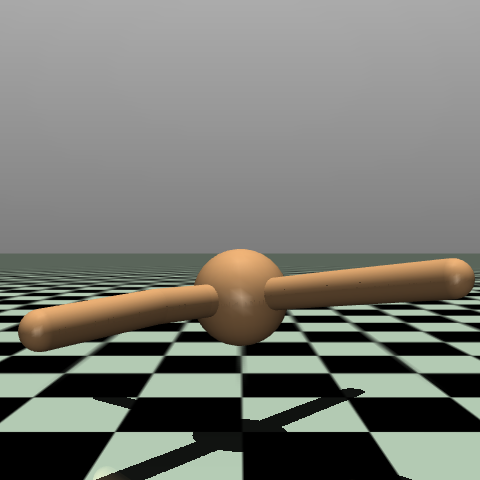

In [ ]:
from IPython.display import Image
Image("ant_test.png")

In [ ]:
import gymnasium as gym
import mujoco

env = gym.make("Ant-v5", render_mode="rgb_array")
# Get the XML string of the current model
xml_path = env.unwrapped.fullpath
print("XML path:", xml_path)

with open(xml_path, 'r') as f:
    xml_content = f.read()

print(xml_content)
env.close()

XML path: /usr/local/lib/python3.12/dist-packages/gymnasium/envs/mujoco/assets/ant.xml
<mujoco model="ant">
  <compiler angle="degree" coordinate="local" inertiafromgeom="true"/>
  <option integrator="RK4" timestep="0.01"/>
  <custom>
    <numeric data="0.0 0.0 0.55 1.0 0.0 0.0 0.0 0.0 1.0 0.0 -1.0 0.0 -1.0 0.0 1.0" name="init_qpos"/>
  </custom>
  <default>
    <joint armature="1" damping="1" limited="true"/>
    <geom conaffinity="0" condim="3" density="5.0" friction="1 0.5 0.5" margin="0.01" rgba="0.8 0.6 0.4 1"/>
  </default>
  <asset>
    <texture builtin="gradient" height="100" rgb1="1 1 1" rgb2="0 0 0" type="skybox" width="100"/>
    <texture builtin="flat" height="1278" mark="cross" markrgb="1 1 1" name="texgeom" random="0.01" rgb1="0.8 0.6 0.4" rgb2="0.8 0.6 0.4" type="cube" width="127"/>
    <texture builtin="checker" height="100" name="texplane" rgb1="0 0 0" rgb2="0.8 0.8 0.8" type="2d" width="100"/>
    <material name="MatPlane" reflectance="0.5" shininess="1" specular="1" 

✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/flat.xml
✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/slope_5.xml
✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/slope_10.xml
✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/slope_15.xml
✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/stairs.xml
✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/envs/rough.xml

Rendering verification frames...
  ✅ flat: frame shape (224, 224, 3)
  ✅ slope_5: frame shape (224, 224, 3)
  ✅ slope_10: frame shape (224, 224, 3)
  ✅ slope_15: frame shape (224, 224, 3)
  ✅ stairs: frame shape (224, 224, 3)
  ✅ rough: frame shape (224, 224, 3)


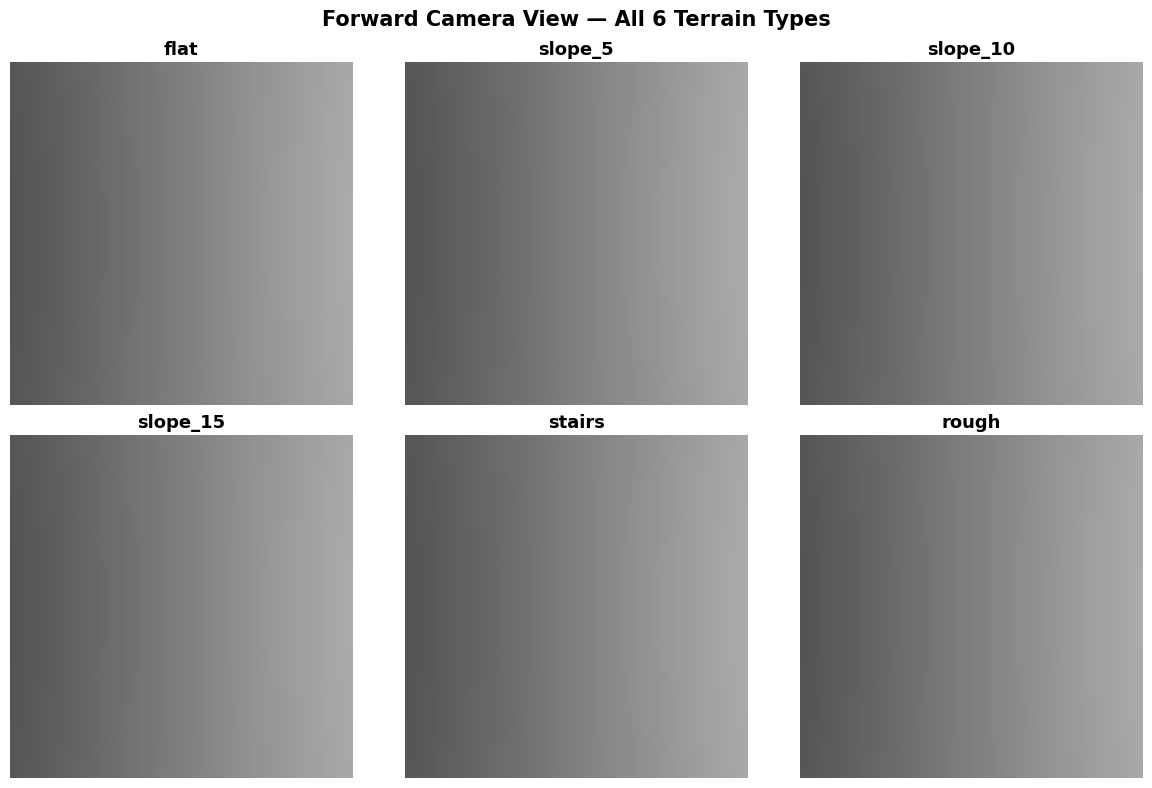


✅ Verification grid saved to /content/drive/MyDrive/terrain_verification.png


In [ ]:
import os
import numpy as np
import mujoco
import matplotlib.pyplot as plt

os.makedirs('/content/drive/MyDrive/PRCV_Final_Project/envs', exist_ok=True)

# ─── Helper: render a frame directly from an XML string ───────────────────────
def render_from_xml(xml_str, camera="forward_cam", w=224, h=224):
    model    = mujoco.MjModel.from_xml_string(xml_str)
    data     = mujoco.MjData(model)
    mujoco.mj_resetData(model, data)
    renderer = mujoco.Renderer(model, height=h, width=w)
    renderer.update_scene(data, camera=camera)
    frame    = renderer.render().copy()
    renderer.close()
    return frame

# ─── Shared XML sections ───────────────────────────────────────────────────────
def make_xml(name, floor_geom, extra_geoms=""):
    """Assembles a full Ant XML with a forward-facing camera and custom terrain."""
    return f"""<mujoco model="ant_{name}">
  <compiler angle="degree" coordinate="local" inertiafromgeom="true"/>
  <option integrator="RK4" timestep="0.01"/>
  <custom>
    <numeric data="0.0 0.0 0.55 1.0 0.0 0.0 0.0 0.0 1.0 0.0 -1.0 0.0 -1.0 0.0 1.0" name="init_qpos"/>
  </custom>
  <default>
    <joint armature="1" damping="1" limited="true"/>
    <geom conaffinity="0" condim="3" density="5.0" friction="1 0.5 0.5" margin="0.01" rgba="0.8 0.6 0.4 1"/>
  </default>
  <asset>
    <texture builtin="gradient" height="100" rgb1="1 1 1" rgb2="0 0 0" type="skybox" width="100"/>
    <texture builtin="flat" height="1278" mark="cross" markrgb="1 1 1" name="texgeom" random="0.01"
             rgb1="0.8 0.6 0.4" rgb2="0.8 0.6 0.4" type="cube" width="127"/>
    <texture builtin="checker" height="100" name="texplane" rgb1="0 0 0" rgb2="0.8 0.8 0.8" type="2d" width="100"/>
    <material name="MatPlane" reflectance="0.5" shininess="1" specular="1" texrepeat="60 60" texture="texplane"/>
    <material name="geom" texture="texgeom" texuniform="true"/>
  </asset>
  <worldbody>
    <light cutoff="100" diffuse="1 1 1" dir="-0 0 -1.3" directional="true" exponent="1" pos="0 0 1.3" specular=".1 .1 .1"/>
    {floor_geom}
    {extra_geoms}
    <body name="torso" pos="0 0 0.75">
      <!--
        forward_cam: mounted on torso, looks in +Y (robot forward), 35° below horizontal.
        pos   = (0, 0.5, 0.15) → 0.5m ahead, 0.15m above torso centre (local frame)
        Camera at ~0.70m world height looking 35° down hits ground ~1.5m ahead.
        xyaxes: cam_X=(1,0,0), cam_Y=(0,0.574,0.819)
        cam_Z = cam_X × cam_Y = (0, -0.819, 0.574)
        looks in -cam_Z = (0, +0.819, -0.574) → forward + 35° down ✓
      -->
      <camera name="forward_cam" mode="fixed" pos="0 0.5 0.15" xyaxes="1 0 0 0 0.574 0.819"/>
      <camera name="track" mode="trackcom" pos="0 -3 0.3" xyaxes="1 0 0 0 0 1"/>
      <geom name="torso_geom" pos="0 0 0" size="0.25" type="sphere"/>
      <joint armature="0" damping="0" limited="false" margin="0.01" name="root" pos="0 0 0" type="free"/>
      <body name="front_left_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 0.2 0.2 0.0" name="aux_1_geom" size="0.08" type="capsule"/>
        <body name="aux_1" pos="0.2 0.2 0">
          <joint axis="0 0 1" name="hip_1" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 0.2 0.2 0.0" name="left_leg_geom" size="0.08" type="capsule"/>
          <body pos="0.2 0.2 0">
            <joint axis="-1 1 0" name="ankle_1" pos="0.0 0.0 0.0" range="30 70" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 0.4 0.4 0.0" name="left_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="front_right_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 -0.2 0.2 0.0" name="aux_2_geom" size="0.08" type="capsule"/>
        <body name="aux_2" pos="-0.2 0.2 0">
          <joint axis="0 0 1" name="hip_2" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 -0.2 0.2 0.0" name="right_leg_geom" size="0.08" type="capsule"/>
          <body pos="-0.2 0.2 0">
            <joint axis="1 1 0" name="ankle_2" pos="0.0 0.0 0.0" range="-70 -30" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 -0.4 0.4 0.0" name="right_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="back_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 -0.2 -0.2 0.0" name="aux_3_geom" size="0.08" type="capsule"/>
        <body name="aux_3" pos="-0.2 -0.2 0">
          <joint axis="0 0 1" name="hip_3" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 -0.2 -0.2 0.0" name="back_leg_geom" size="0.08" type="capsule"/>
          <body pos="-0.2 -0.2 0">
            <joint axis="-1 1 0" name="ankle_3" pos="0.0 0.0 0.0" range="-70 -30" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 -0.4 -0.4 0.0" name="third_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="right_back_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 0.2 -0.2 0.0" name="aux_4_geom" size="0.08" type="capsule"/>
        <body name="aux_4" pos="0.2 -0.2 0">
          <joint axis="0 0 1" name="hip_4" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 0.2 -0.2 0.0" name="rightback_leg_geom" size="0.08" type="capsule"/>
          <body pos="0.2 -0.2 0">
            <joint axis="1 1 0" name="ankle_4" pos="0.0 0.0 0.0" range="30 70" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 0.4 -0.4 0.0" name="fourth_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_4" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_4" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_1" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_1" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_2" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_2" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_3" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_3" gear="150"/>
  </actuator>
</mujoco>"""

# ─── Terrain definitions ───────────────────────────────────────────────────────

FLAT_FLOOR   = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane"/>'
SLOPE5_FLOOR = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="5 0 0"/>'
SLOPE10_FLOOR= '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="10 0 0"/>'
SLOPE15_FLOOR= '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="15 0 0"/>'

# Stairs: 5 steps, each 0.1m rise, 0.8m deep, starting 2m ahead of robot (+Y)
# Each box covers the full width (6m) and sits on the flat floor beneath
STAIR_GEOMS = "\n    ".join([
    f'<geom type="box" conaffinity="1" condim="3" '
    f'pos="0 {2.0 + i*0.8:.1f} {(i+1)*0.05:.3f}" '
    f'size="3 0.4 {(i+1)*0.05:.3f}" '
    f'rgba="0.55 0.55 0.70 1"/>'
    for i in range(5)
])

# Rough terrain: 45 random box bumps scattered from y=1.5 to y=7 ahead of robot
np.random.seed(42)
ROUGH_GEOMS = "\n    ".join([
    f'<geom type="box" conaffinity="1" condim="3" '
    f'pos="{np.random.uniform(-3,3):.2f} {np.random.uniform(1.5,7.0):.2f} {(h:=np.random.uniform(0.04,0.14))/2:.3f}" '
    f'size="{np.random.uniform(0.1,0.28):.2f} {np.random.uniform(0.1,0.28):.2f} {h/2:.3f}" '
    f'rgba="0.50 0.40 0.30 1"/>'
    for _ in range(45)
])

# ─── Build and save all 6 XMLs ────────────────────────────────────────────────
terrains = {
    "flat":     make_xml("flat",     FLAT_FLOOR),
    "slope_5":  make_xml("slope_5",  SLOPE5_FLOOR),
    "slope_10": make_xml("slope_10", SLOPE10_FLOOR),
    "slope_15": make_xml("slope_15", SLOPE15_FLOOR),
    "stairs":   make_xml("stairs",   FLAT_FLOOR,   STAIR_GEOMS),
    "rough":    make_xml("rough",    FLAT_FLOOR,   ROUGH_GEOMS),
}

for name, xml in terrains.items():
    path = f"/content/drive/MyDrive/PRCV_Final_Project/envs/{name}.xml"
    with open(path, "w") as f:
        f.write(xml)
    print(f"✅ Saved: {path}")

# ─── Verify: render one forward-camera frame per terrain ──────────────────────
print("\nRendering verification frames...")
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

for i, (name, xml) in enumerate(terrains.items()):
    try:
        frame = render_from_xml(xml, camera="forward_cam")
        axes[i].imshow(frame)
        axes[i].set_title(name, fontsize=13, fontweight='bold')
        axes[i].axis('off')
        print(f"  ✅ {name}: frame shape {frame.shape}")
    except Exception as e:
        axes[i].set_title(f"{name} — ERROR", color='red')
        print(f"  ❌ {name}: {e}")

plt.suptitle("Forward Camera View — All 6 Terrain Types", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/terrain_verification.png", dpi=120, bbox_inches='tight')
plt.show()
print("\n✅ Verification grid saved to /content/drive/MyDrive/terrain_verification.png")

Torso world position after init_qpos fix: [0.   0.   0.55]
data.qpos[:7] = [0.   0.   0.55 1.   0.   0.   0.  ]

Cameras in model:
  [0] forward_cam
  [1] track
  Rendered 'forward_cam': shape=(224, 224, 3), mean_brightness=119.9
  Rendered 'track': shape=(224, 224, 3), mean_brightness=122.2
  Rendered 'camera=-1': shape=(224, 224, 3), mean_brightness=117.4


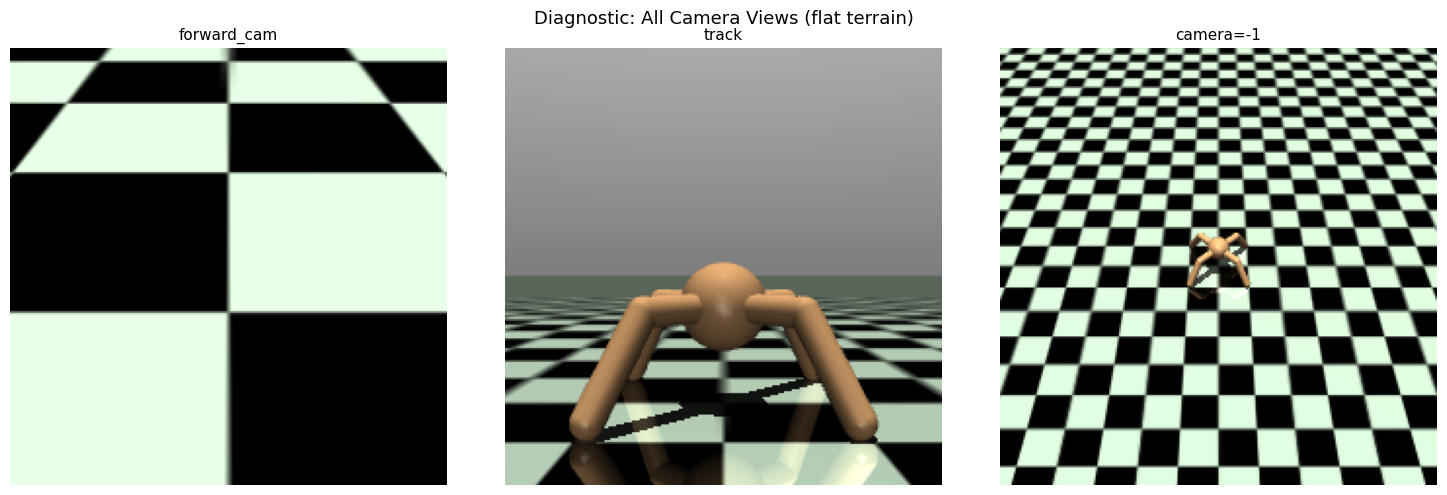

In [ ]:
import mujoco, numpy as np, matplotlib.pyplot as plt

INIT_QPOS = [0.0, 0.0, 0.55, 1.0, 0.0, 0.0, 0.0,
             0.0, 1.0, 0.0, -1.0, 0.0, -1.0, 0.0, 1.0]

# Load flat terrain XML
with open("/content/drive/MyDrive/PRCV_Final_Project/envs/flat.xml") as f:
    xml = f.read()

model = mujoco.MjModel.from_xml_string(xml)
data  = mujoco.MjData(model)
mujoco.mj_resetData(model, data)
data.qpos[:len(INIT_QPOS)] = INIT_QPOS
mujoco.mj_forward(model, data)

# ── 1. Print torso world position after fix ───────────────────────────────────
torso_id  = mujoco.mj_name2id(model, mujoco.mjtObj.mjOBJ_BODY, "torso")
torso_pos = data.xpos[torso_id]
print(f"Torso world position after init_qpos fix: {torso_pos}")
print(f"data.qpos[:7] = {data.qpos[:7]}")

# ── 2. Print all camera names in the model ────────────────────────────────────
print(f"\nCameras in model:")
for i in range(model.ncam):
    name = mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_CAMERA, i)
    print(f"  [{i}] {name}")

# ── 3. Render from ALL cameras + free camera, show side by side ───────────────
renderer = mujoco.Renderer(model, height=224, width=224)

cameras_to_try = []
# Add all named cameras
for i in range(model.ncam):
    cameras_to_try.append(mujoco.mj_id2name(model, mujoco.mjtObj.mjOBJ_CAMERA, i))
# Add free camera (default, no name needed — pass camera=-1)
cameras_to_try.append(-1)   # -1 = default free camera

n = len(cameras_to_try)
fig, axes = plt.subplots(1, n, figsize=(5*n, 5))
if n == 1:
    axes = [axes]

for ax, cam in zip(axes, cameras_to_try):
    renderer.update_scene(data, camera=cam)
    frame = renderer.render().copy()
    label = f"camera={cam}" if cam == -1 else cam
    ax.imshow(frame)
    ax.set_title(label, fontsize=11)
    ax.axis("off")
    print(f"  Rendered '{label}': shape={frame.shape}, "
          f"mean_brightness={frame.mean():.1f}")

renderer.close()
plt.suptitle("Diagnostic: All Camera Views (flat terrain)", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/camera_debug.png", dpi=120)
plt.show()

✅ Rebuilt: flat.xml
✅ Rebuilt: slope_5.xml
✅ Rebuilt: slope_10.xml
✅ Rebuilt: slope_15.xml
✅ Rebuilt: stairs.xml
✅ Rebuilt: rough.xml


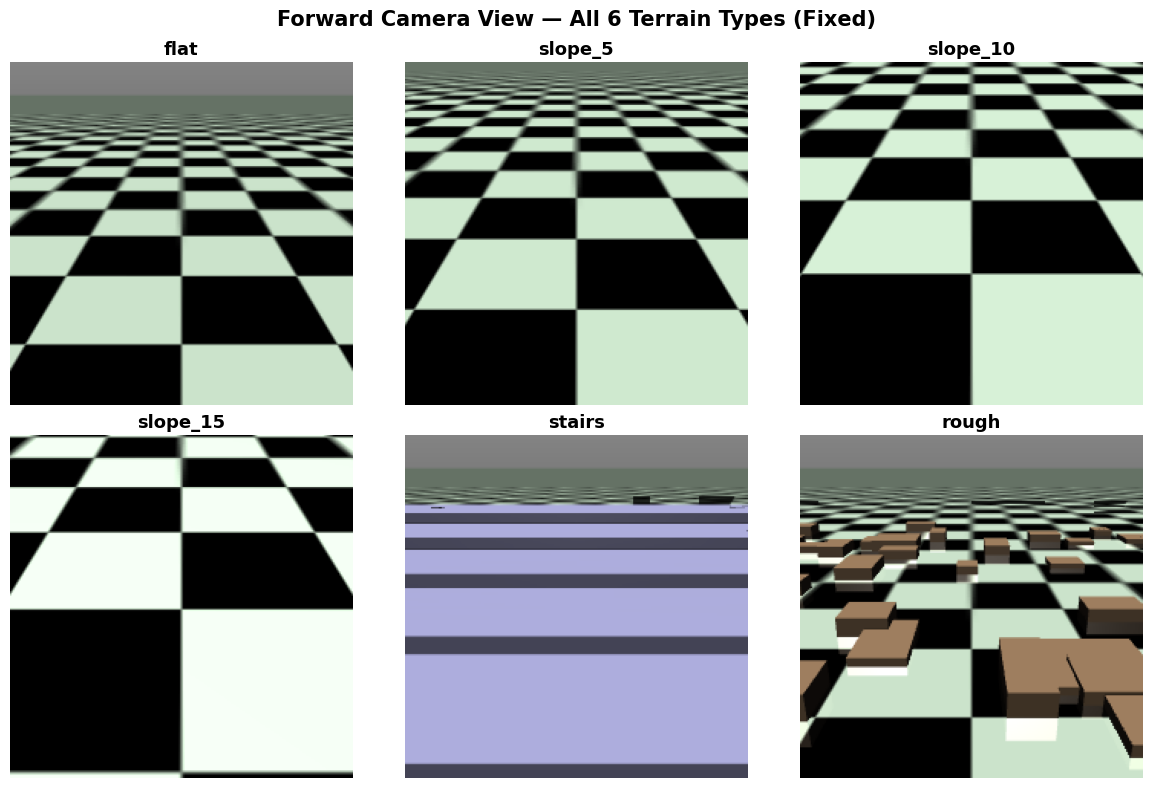

✅ Done — terrain_verification_v2.png saved


In [ ]:
# ── Only change: camera pos and xyaxes inside make_xml ───────────────────────
#
# OLD: pos="0 0.5 0.15"  35° down  → camera at world z=0.70m, too close/steep
# NEW: pos="0 0.5 0.5"   20° down  → camera at world z=1.05m, sees 3-5m ahead
#
# xyaxes="1 0 0 0 0.342 0.940"  (20° downward tilt)
#   cam_X = (1, 0, 0)
#   cam_Y = (0, 0.342, 0.940)
#   cam_Z = cam_X × cam_Y = (0, -0.940, 0.342)
#   looks in -cam_Z = (0, +0.940, -0.342) → forward + 20° down
#   at world height 1.05m → ground contact ~3.4m ahead ✓

def make_xml(name, floor_geom, extra_geoms=""):
    return f"""<mujoco model="ant_{name}">
  <compiler angle="degree" coordinate="local" inertiafromgeom="true"/>
  <option integrator="RK4" timestep="0.01"/>
  <custom>
    <numeric data="0.0 0.0 0.55 1.0 0.0 0.0 0.0 0.0 1.0 0.0 -1.0 0.0 -1.0 0.0 1.0" name="init_qpos"/>
  </custom>
  <default>
    <joint armature="1" damping="1" limited="true"/>
    <geom conaffinity="0" condim="3" density="5.0" friction="1 0.5 0.5" margin="0.01" rgba="0.8 0.6 0.4 1"/>
  </default>
  <asset>
    <texture builtin="gradient" height="100" rgb1="1 1 1" rgb2="0 0 0" type="skybox" width="100"/>
    <texture builtin="flat" height="1278" mark="cross" markrgb="1 1 1" name="texgeom" random="0.01"
             rgb1="0.8 0.6 0.4" rgb2="0.8 0.6 0.4" type="cube" width="127"/>
    <texture builtin="checker" height="100" name="texplane" rgb1="0 0 0" rgb2="0.8 0.8 0.8" type="2d" width="100"/>
    <material name="MatPlane" reflectance="0.5" shininess="1" specular="1" texrepeat="60 60" texture="texplane"/>
    <material name="geom" texture="texgeom" texuniform="true"/>
  </asset>
  <worldbody>
    <light cutoff="100" diffuse="1 1 1" dir="-0 0 -1.3" directional="true" exponent="1" pos="0 0 1.3" specular=".1 .1 .1"/>
    {floor_geom}
    {extra_geoms}
    <body name="torso" pos="0 0 0.75">
      <camera name="forward_cam" mode="fixed" pos="0 0.5 0.5" xyaxes="1 0 0 0 0.342 0.940"/>
      <camera name="track" mode="trackcom" pos="0 -3 0.3" xyaxes="1 0 0 0 0 1"/>
      <geom name="torso_geom" pos="0 0 0" size="0.25" type="sphere"/>
      <joint armature="0" damping="0" limited="false" margin="0.01" name="root" pos="0 0 0" type="free"/>
      <body name="front_left_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 0.2 0.2 0.0" name="aux_1_geom" size="0.08" type="capsule"/>
        <body name="aux_1" pos="0.2 0.2 0">
          <joint axis="0 0 1" name="hip_1" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 0.2 0.2 0.0" name="left_leg_geom" size="0.08" type="capsule"/>
          <body pos="0.2 0.2 0">
            <joint axis="-1 1 0" name="ankle_1" pos="0.0 0.0 0.0" range="30 70" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 0.4 0.4 0.0" name="left_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="front_right_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 -0.2 0.2 0.0" name="aux_2_geom" size="0.08" type="capsule"/>
        <body name="aux_2" pos="-0.2 0.2 0">
          <joint axis="0 0 1" name="hip_2" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 -0.2 0.2 0.0" name="right_leg_geom" size="0.08" type="capsule"/>
          <body pos="-0.2 0.2 0">
            <joint axis="1 1 0" name="ankle_2" pos="0.0 0.0 0.0" range="-70 -30" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 -0.4 0.4 0.0" name="right_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="back_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 -0.2 -0.2 0.0" name="aux_3_geom" size="0.08" type="capsule"/>
        <body name="aux_3" pos="-0.2 -0.2 0">
          <joint axis="0 0 1" name="hip_3" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 -0.2 -0.2 0.0" name="back_leg_geom" size="0.08" type="capsule"/>
          <body pos="-0.2 -0.2 0">
            <joint axis="-1 1 0" name="ankle_3" pos="0.0 0.0 0.0" range="-70 -30" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 -0.4 -0.4 0.0" name="third_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
      <body name="right_back_leg" pos="0 0 0">
        <geom fromto="0.0 0.0 0.0 0.2 -0.2 0.0" name="aux_4_geom" size="0.08" type="capsule"/>
        <body name="aux_4" pos="0.2 -0.2 0">
          <joint axis="0 0 1" name="hip_4" pos="0.0 0.0 0.0" range="-30 30" type="hinge"/>
          <geom fromto="0.0 0.0 0.0 0.2 -0.2 0.0" name="rightback_leg_geom" size="0.08" type="capsule"/>
          <body pos="0.2 -0.2 0">
            <joint axis="1 1 0" name="ankle_4" pos="0.0 0.0 0.0" range="30 70" type="hinge"/>
            <geom fromto="0.0 0.0 0.0 0.4 -0.4 0.0" name="fourth_ankle_geom" size="0.08" type="capsule"/>
          </body>
        </body>
      </body>
    </body>
  </worldbody>
  <actuator>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_4" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_4" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_1" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_1" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_2" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_2" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="hip_3" gear="150"/>
    <motor ctrllimited="true" ctrlrange="-1.0 1.0" joint="ankle_3" gear="150"/>
  </actuator>
</mujoco>"""

# ── Terrain definitions (unchanged) ──────────────────────────────────────────
FLAT_FLOOR    = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane"/>'
SLOPE5_FLOOR  = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="5 0 0"/>'
SLOPE10_FLOOR = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="10 0 0"/>'
SLOPE15_FLOOR = '<geom conaffinity="1" condim="3" material="MatPlane" name="floor" pos="0 0 0" rgba="0.8 0.9 0.8 1" size="40 40 40" type="plane" euler="15 0 0"/>'

import numpy as np
STAIR_GEOMS = "\n    ".join([
    f'<geom type="box" conaffinity="1" condim="3" '
    f'pos="0 {2.0 + i*0.8:.1f} {(i+1)*0.05:.3f}" '
    f'size="3 0.4 {(i+1)*0.05:.3f}" rgba="0.55 0.55 0.70 1"/>'
    for i in range(5)
])
np.random.seed(42)
ROUGH_GEOMS = "\n    ".join([
    f'<geom type="box" conaffinity="1" condim="3" '
    f'pos="{np.random.uniform(-3,3):.2f} {np.random.uniform(1.5,7.0):.2f} {(h:=np.random.uniform(0.04,0.14))/2:.3f}" '
    f'size="{np.random.uniform(0.1,0.28):.2f} {np.random.uniform(0.1,0.28):.2f} {h/2:.3f}" '
    f'rgba="0.50 0.40 0.30 1"/>'
    for _ in range(45)
])

# ── Rebuild and save all 6 XMLs ───────────────────────────────────────────────
terrains = {
    "flat":     make_xml("flat",     FLAT_FLOOR),
    "slope_5":  make_xml("slope_5",  SLOPE5_FLOOR),
    "slope_10": make_xml("slope_10", SLOPE10_FLOOR),
    "slope_15": make_xml("slope_15", SLOPE15_FLOOR),
    "stairs":   make_xml("stairs",   FLAT_FLOOR,   STAIR_GEOMS),
    "rough":    make_xml("rough",    FLAT_FLOOR,   ROUGH_GEOMS),
}
for name, xml in terrains.items():
    with open(f"/content/drive/MyDrive/PRCV_Final_Project/envs/{name}.xml", "w") as f:
        f.write(xml)
    print(f"✅ Rebuilt: {name}.xml")

# ── Re-verify all 6 forward camera views ─────────────────────────────────────
import mujoco, matplotlib.pyplot as plt

INIT_QPOS = [0.0,0.0,0.55,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0]

def render_from_xml(xml_str, camera="forward_cam", w=224, h=224):
    model = mujoco.MjModel.from_xml_string(xml_str)
    data  = mujoco.MjData(model)
    mujoco.mj_resetData(model, data)
    data.qpos[:len(INIT_QPOS)] = INIT_QPOS
    mujoco.mj_forward(model, data)
    renderer = mujoco.Renderer(model, height=h, width=w)
    renderer.update_scene(data, camera=camera)
    frame = renderer.render().copy()
    renderer.close()
    return frame

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for ax, (name, xml) in zip(axes.flatten(), terrains.items()):
    frame = render_from_xml(xml)
    ax.imshow(frame)
    ax.set_title(name, fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle("Forward Camera View — All 6 Terrain Types (Fixed)", fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/terrain_verification_v2.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Done — terrain_verification_v2.png saved")

  ✅ flat        1000 images  [106.5s elapsed]
  ✅ slope_5     1000 images  [219.7s elapsed]
  ✅ slope_10    1000 images  [319.9s elapsed]
  ✅ slope_15    1000 images  [407.1s elapsed]
  ✅ stairs      1000 images  [508.8s elapsed]
  ✅ rough       1000 images  [615.8s elapsed]

✅ Dataset complete: 6000 images across 6 classes
   Total time: 615.8s
   Saved to: /content/drive/MyDrive/PRCV_Final_Project/data/


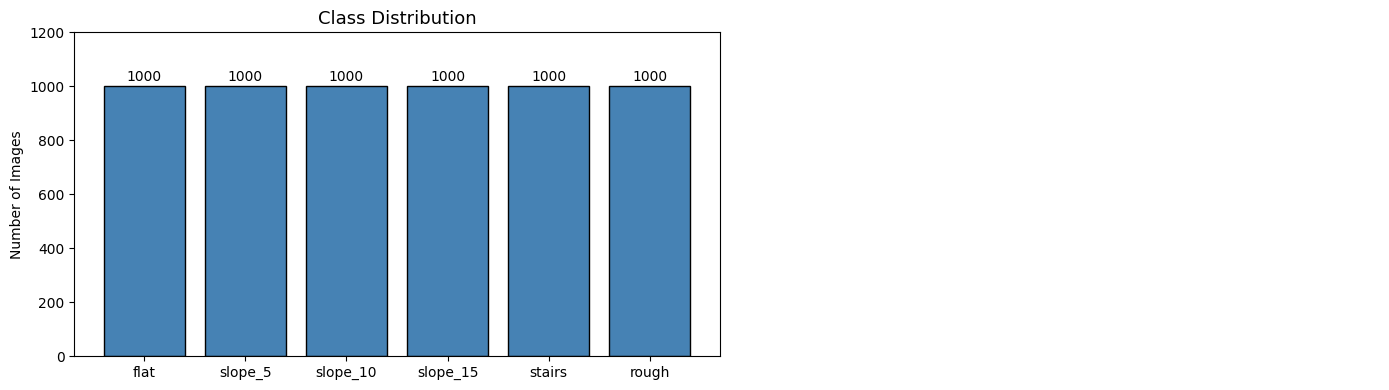

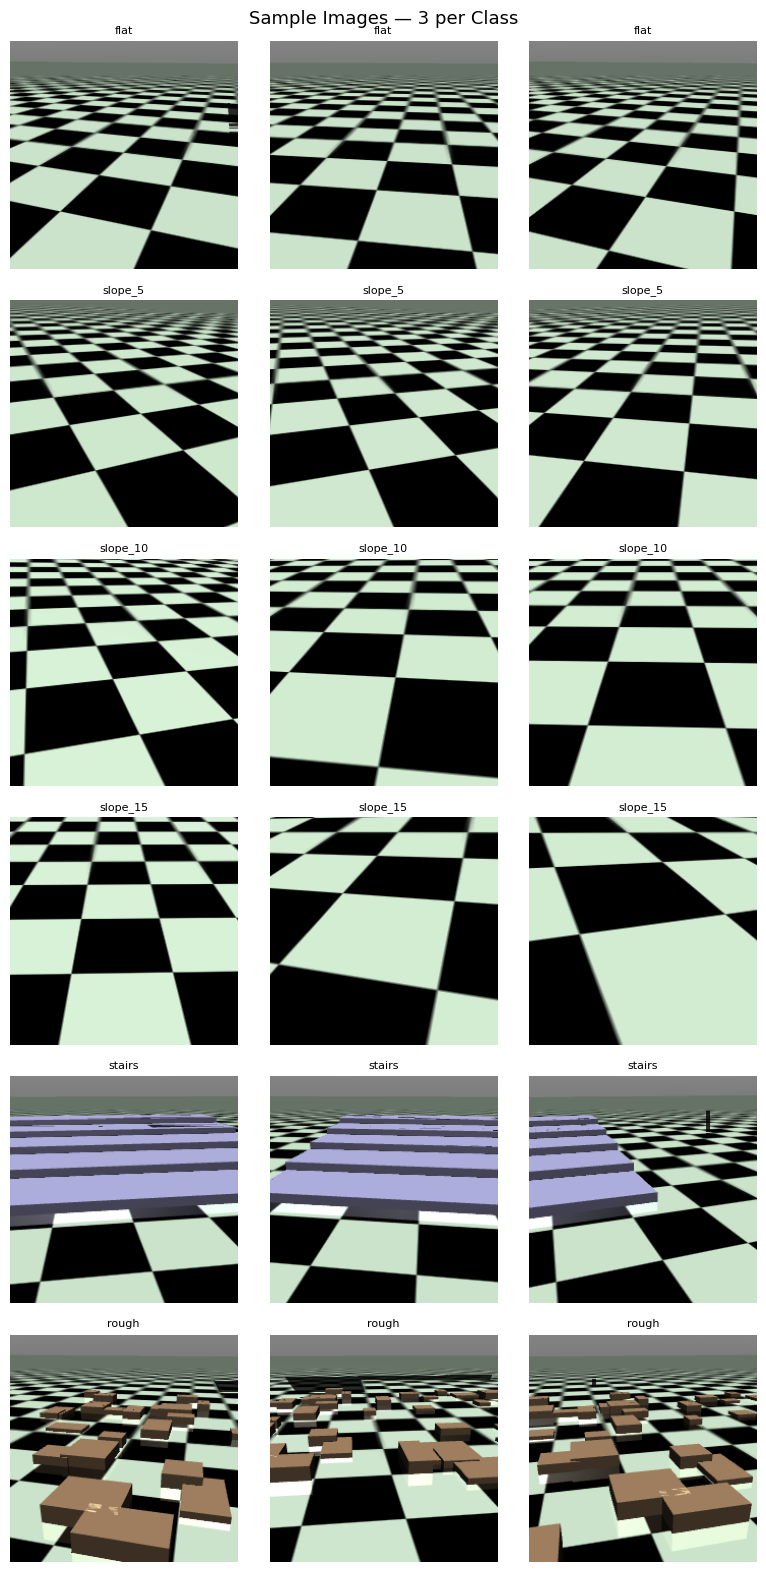

✅ Sample grid saved to /content/drive/MyDrive/PRCV_Final_Project/dataset_samples.png


In [ ]:
import os, time
import numpy as np
import mujoco
import cv2
import matplotlib.pyplot as plt

# ── Config ────────────────────────────────────────────────────────────────────
SAMPLES_PER_CLASS = 1000
IMG_SIZE          = 224
OUTPUT_DIR        = "/content/drive/MyDrive/PRCV_Final_Project/data"
TERRAIN_NAMES     = ["flat", "slope_5", "slope_10", "slope_15", "stairs", "rough"]
INIT_QPOS         = [0.0,0.0,0.55,1.0,0.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0]

# ── Pose randomization bounds ─────────────────────────────────────────────────
# Vary robot position (x, y) and yaw angle to get diverse viewpoints.
# Keep z fixed so robot stays on/above terrain.
# Yaw range kept small (±25°) so camera still faces mostly forward.
POS_X_RANGE  = (-2.0,  2.0)   # sideways variation
POS_Y_RANGE  = (-1.5,  1.5)   # forward/back variation
YAW_RANGE    = (-25,   25)    # degrees — small yaw keeps terrain in view

def random_quat_yaw(yaw_deg):
    """Returns quaternion (w,x,y,z) for a pure yaw rotation around Z axis."""
    a = np.radians(yaw_deg) / 2
    return [np.cos(a), 0.0, 0.0, np.sin(a)]

def randomize_qpos(base_qpos, rng):
    q = base_qpos.copy()
    q[0] = rng.uniform(*POS_X_RANGE)                      # x
    q[1] = rng.uniform(*POS_Y_RANGE)                      # y
    # z stays at 0.55 (robot height above flat ground)
    yaw        = rng.uniform(*YAW_RANGE)
    q[3:7]     = random_quat_yaw(yaw)                     # quaternion
    return q

def capture_frame(renderer, model, data, qpos):
    """Set qpos, step physics forward, render and return RGB frame."""
    data.qpos[:] = qpos
    mujoco.mj_forward(model, data)
    renderer.update_scene(data, camera="forward_cam")
    return renderer.render().copy()

# ── Main dataset generation loop ──────────────────────────────────────────────
os.makedirs(OUTPUT_DIR, exist_ok=True)
rng        = np.random.default_rng(seed=42)
total_imgs = 0
t_start    = time.time()
counts     = {}

for terrain in TERRAIN_NAMES:
    xml_path  = f"/content/drive/MyDrive/PRCV_Final_Project/envs/{terrain}.xml"
    class_dir = f"{OUTPUT_DIR}/{terrain}"
    os.makedirs(class_dir, exist_ok=True)

    with open(xml_path) as f:
        xml = f.read()

    model    = mujoco.MjModel.from_xml_string(xml)
    data     = mujoco.MjData(model)
    renderer = mujoco.Renderer(model, height=IMG_SIZE, width=IMG_SIZE)

    for i in range(SAMPLES_PER_CLASS):
        mujoco.mj_resetData(model, data)
        qpos = randomize_qpos(np.array(INIT_QPOS, dtype=np.float64), rng)
        frame = capture_frame(renderer, model, data, qpos)

        # Save as PNG (lossless)
        save_path = f"{class_dir}/{i:04d}.png"
        cv2.imwrite(save_path, cv2.cvtColor(frame, cv2.COLOR_RGB2BGR))

    renderer.close()
    counts[terrain] = SAMPLES_PER_CLASS
    total_imgs     += SAMPLES_PER_CLASS
    elapsed         = time.time() - t_start
    print(f"  ✅ {terrain:10s}  {SAMPLES_PER_CLASS} images  "
          f"[{elapsed:.1f}s elapsed]")

print(f"\n✅ Dataset complete: {total_imgs} images across {len(TERRAIN_NAMES)} classes")
print(f"   Total time: {time.time()-t_start:.1f}s")
print(f"   Saved to: {OUTPUT_DIR}/")

# ── Class distribution bar chart ──────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Bar chart
axes[0].bar(counts.keys(), counts.values(), color='steelblue', edgecolor='black')
axes[0].set_title("Class Distribution", fontsize=13)
axes[0].set_ylabel("Number of Images")
axes[0].set_ylim(0, 1200)
for i, (k, v) in enumerate(counts.items()):
    axes[0].text(i, v + 20, str(v), ha='center', fontsize=10)

# Sample grid — 3 random images from each class
sample_imgs = []
sample_labels = []
for terrain in TERRAIN_NAMES:
    class_dir = f"{OUTPUT_DIR}/{terrain}"
    files     = sorted(os.listdir(class_dir))
    chosen    = rng.choice(files, 3, replace=False)
    for fname in chosen:
        img = cv2.imread(f"{class_dir}/{fname}")
        sample_imgs.append(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        sample_labels.append(terrain)

axes[1].axis('off')
plt.tight_layout()

# Show sample grid separately
fig2, axes2 = plt.subplots(6, 3, figsize=(8, 16))
for ax, img, label in zip(axes2.flatten(), sample_imgs, sample_labels):
    ax.imshow(img)
    ax.set_title(label, fontsize=8)
    ax.axis('off')

plt.suptitle("Sample Images — 3 per Class", fontsize=13)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/dataset_samples.png", dpi=100, bbox_inches='tight')
plt.show()
print("✅ Sample grid saved to /content/drive/MyDrive/PRCV_Final_Project/dataset_samples.png")

Dataset split (total=6000):
  Train : 4,200 images  (132 batches)
  Val   : 900 images  (29 batches)
  Test  : 900 images  (29 batches)
  Classes: ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']


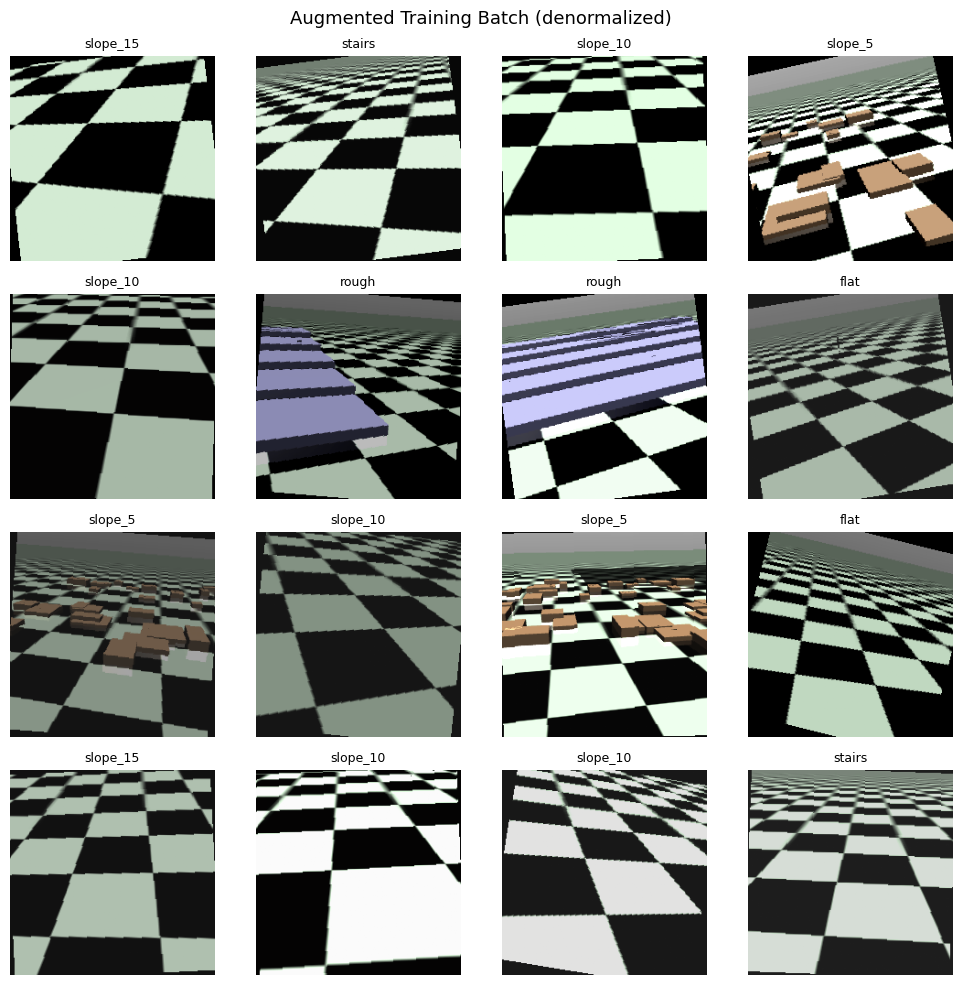

✅ Augmented batch saved to /content/drive/MyDrive/PRCV_Final_Project/augmented_batch.png

Class distribution in training set:
  flat        : 697
  slope_5     : 705
  slope_10    : 687
  slope_15    : 710
  stairs      : 704
  rough       : 697

✅ Task 3 complete — DataLoaders ready for training.
   Batch shape: torch.Size([32, 3, 224, 224])


In [ ]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

# ── Config ────────────────────────────────────────────────────────────────────
DATA_DIR    = "/content/drive/MyDrive/PRCV_Final_Project/data"
IMG_SIZE    = 224
BATCH_SIZE  = 32
NUM_WORKERS = 2
SEED        = 42

# ImageNet mean/std — required for pretrained ResNet18 / MobileNetV2
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Class names (must match folder names under DATA_DIR)
CLASSES = ["flat", "slope_5", "slope_10", "slope_15", "stairs", "rough"]

# ── Transforms ────────────────────────────────────────────────────────────────
# Training: augmentation to improve generalization
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# Validation/Test: no augmentation — only resize + normalize
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Dataset splits ────────────────────────────────────────────────────────────
def make_dataloaders(data_dir=DATA_DIR, batch_size=BATCH_SIZE):
    """
    Loads the terrain dataset, splits into train/val/test (70/15/15),
    and returns three DataLoaders with appropriate transforms.
    """
    torch.manual_seed(SEED)

    # Load full dataset once (no transform yet) just to get indices
    full_dataset = datasets.ImageFolder(root=data_dir)
    n            = len(full_dataset)
    n_train      = int(0.70 * n)
    n_val        = int(0.15 * n)
    n_test       = n - n_train - n_val

    # Split indices reproducibly
    train_idx, val_idx, test_idx = random_split(
        range(n), [n_train, n_val, n_test],
        generator=torch.Generator().manual_seed(SEED)
    )

    # Rebuild datasets with correct transforms per split
    train_ds = datasets.ImageFolder(root=data_dir, transform=train_transform)
    val_ds   = datasets.ImageFolder(root=data_dir, transform=eval_transform)
    test_ds  = datasets.ImageFolder(root=data_dir, transform=eval_transform)

    from torch.utils.data import Subset
    train_ds = Subset(train_ds, train_idx.indices)
    val_ds   = Subset(val_ds,   val_idx.indices)
    test_ds  = Subset(test_ds,  test_idx.indices)

    train_loader = DataLoader(train_ds, batch_size=batch_size,
                              shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size,
                              shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

    print(f"Dataset split (total={n}):")
    print(f"  Train : {len(train_ds):,} images  ({len(train_loader)} batches)")
    print(f"  Val   : {len(val_ds):,} images  ({len(val_loader)} batches)")
    print(f"  Test  : {len(test_ds):,} images  ({len(test_loader)} batches)")
    print(f"  Classes: {full_dataset.classes}")

    return train_loader, val_loader, test_loader

# ── Verify: visualize augmented batch ────────────────────────────────────────
def show_augmented_batch(train_loader, n_show=16):
    """Shows a grid of augmented training images (denormalized for display)."""
    images, labels = next(iter(train_loader))

    # Denormalize for display
    mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
    std  = torch.tensor(IMAGENET_STD).view(3,1,1)
    imgs = images[:n_show] * std + mean
    imgs = imgs.clamp(0, 1).permute(0, 2, 3, 1).numpy()

    fig, axes = plt.subplots(4, 4, figsize=(10, 10))
    for ax, img, lbl in zip(axes.flatten(), imgs, labels[:n_show]):
        ax.imshow(img)
        ax.set_title(CLASSES[lbl], fontsize=9)
        ax.axis('off')

    plt.suptitle("Augmented Training Batch (denormalized)", fontsize=13)
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/augmented_batch.png", dpi=100, bbox_inches='tight')
    plt.show()
    print("✅ Augmented batch saved to /content/drive/MyDrive/PRCV_Final_Project/augmented_batch.png")

# ── Class distribution check ─────────────────────────────────────────────────
def check_class_balance(train_loader):
    """Counts samples per class in the training set."""
    from collections import Counter
    counts = Counter()
    for _, labels in train_loader:
        counts.update(labels.numpy())
    print("\nClass distribution in training set:")
    for cls_idx, cnt in sorted(counts.items()):
        print(f"  {CLASSES[cls_idx]:12s}: {cnt}")

# ── Run ───────────────────────────────────────────────────────────────────────
train_loader, val_loader, test_loader = make_dataloaders()
show_augmented_batch(train_loader)
check_class_balance(train_loader)

print("\n✅ Task 3 complete — DataLoaders ready for training.")
print(f"   Batch shape: {next(iter(train_loader))[0].shape}")

Device  : cuda
Classes : ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]



Model   : ResNet18  (pretrained=True, fine-tune all layers)
Params  : 11,179,590 total  / 11,179,590 trainable

Epoch    T-Loss    T-Acc    V-Loss    V-Acc    Time
-------------------------------------------------------
    1    0.1146   96.8%    0.0031  100.0%    249s  ✅ best
    2    0.0024  100.0%    0.0008  100.0%    298s
    3    0.0011  100.0%    0.0004  100.0%    346s
    4    0.0009  100.0%    0.0003  100.0%    394s
    5    0.0126   99.7%    0.0007  100.0%    434s
    6    0.0076   99.9%    0.0002  100.0%    474s
    7    0.0010  100.0%    0.0002  100.0%    512s
    8    0.0013  100.0%    0.0001  100.0%    553s
    9    0.0009  100.0%    0.0001  100.0%    594s
   10    0.0004  100.0%    0.0001  100.0%    632s
   11    0.0014  100.0%    0.0001  100.0%    671s
   12    0.0020  100.0%    0.0001  100.0%    709s
   13    0.0003  100.0%    0.0000  100.0%    748s
   14    0.0002  100.0%    0.0000  100.0%    787s
   15    0.0002  100.0%    0.0000  100.0%    824s
   16    0.0002  100.

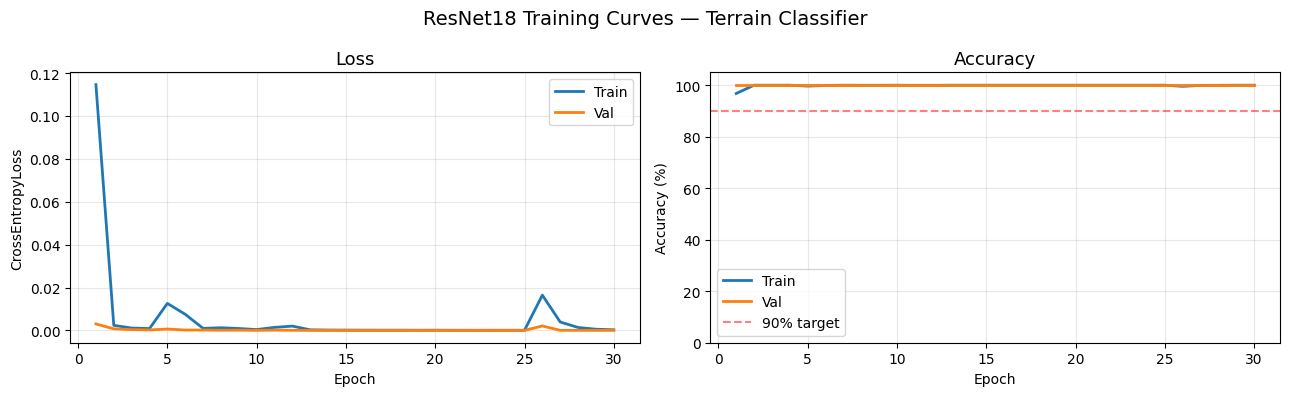

✅ Training curves saved to /content/drive/MyDrive/PRCV_Final_Project/training_curves_resnet18.png


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import matplotlib.pyplot as plt
import time, copy

# ── Must run after Task 3 cell (train_loader, val_loader, test_loader defined) ─

# Fix class ordering to match ImageFolder's alphabetical sort
CLASSES = ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']
NUM_CLASSES = len(CLASSES)

DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NUM_EPOCHS = 30
LR         = 1e-4

print(f"Device  : {DEVICE}")
print(f"Classes : {CLASSES}")

# ── Model: ResNet18 with replaced classifier head ─────────────────────────────
def build_resnet18(num_classes=NUM_CLASSES, freeze_backbone=False):
    """
    Load ImageNet-pretrained ResNet18.
    Replace the final FC layer (512 → num_classes).
    Optionally freeze all layers except the new head.
    """
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False

    # Replace classifier head — this layer always trains
    model.fc = nn.Linear(512, num_classes)
    return model.to(DEVICE)

# Strategy: fine-tune the whole network (not just head)
# With 4,200 training images and ImageNet pretraining this converges well
model = build_resnet18(freeze_backbone=False)
print(f"\nModel   : ResNet18  (pretrained=True, fine-tune all layers)")
print(f"Params  : {sum(p.numel() for p in model.parameters()):,} total  "
      f"/ {sum(p.numel() for p in model.parameters() if p.requires_grad):,} trainable")

# ── Loss + Optimizer + Scheduler ─────────────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-4)

# Reduce LR by 0.5 if val loss doesn't improve for 5 epochs
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

# ── Training loop ─────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0.0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        outputs     = model(imgs)
        loss        = criterion(outputs, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

# ── Run training ──────────────────────────────────────────────────────────────
history     = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0
best_weights = None
t0           = time.time()

print(f"\n{'Epoch':>5}  {'T-Loss':>8}  {'T-Acc':>7}  {'V-Loss':>8}  {'V-Acc':>7}  {'Time':>6}")
print("-" * 55)

for epoch in range(1, NUM_EPOCHS + 1):
    t_loss, t_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    v_loss, v_acc = evaluate(model, val_loader, criterion)
    scheduler.step(v_loss)

    history["train_loss"].append(t_loss)
    history["val_loss"].append(v_loss)
    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    # Save best checkpoint
    if v_acc > best_val_acc:
        best_val_acc  = v_acc
        best_weights  = copy.deepcopy(model.state_dict())
        torch.save(best_weights, "/content/drive/MyDrive/PRCV_Final_Project/resnet18_terrain_best.pth")
        flag = "  ✅ best"
    else:
        flag = ""

    elapsed = time.time() - t0
    print(f"{epoch:>5}  {t_loss:>8.4f}  {t_acc:>6.1%}  {v_loss:>8.4f}  {v_acc:>6.1%}  {elapsed:>5.0f}s{flag}")

print(f"\n✅ Training complete.  Best val accuracy: {best_val_acc:.2%}")

# ── Reload best weights + evaluate on test set ────────────────────────────────
model.load_state_dict(best_weights)
test_loss, test_acc = evaluate(model, test_loader, criterion)
print(f"✅ Test accuracy (best checkpoint): {test_acc:.2%}")

# ── Plot training curves ───────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

epochs = range(1, NUM_EPOCHS + 1)
ax1.plot(epochs, history["train_loss"], label="Train", linewidth=2)
ax1.plot(epochs, history["val_loss"],   label="Val",   linewidth=2)
ax1.set_title("Loss", fontsize=13)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("CrossEntropyLoss")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, [a*100 for a in history["train_acc"]], label="Train", linewidth=2)
ax2.plot(epochs, [a*100 for a in history["val_acc"]],   label="Val",   linewidth=2)
ax2.axhline(y=90, color='red', linestyle='--', alpha=0.5, label="90% target")
ax2.set_title("Accuracy", fontsize=13)
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")
ax2.set_ylim(0, 105); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("ResNet18 Training Curves — Terrain Classifier", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/training_curves_resnet18.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Training curves saved to /content/drive/MyDrive/PRCV_Final_Project/training_curves_resnet18.png")

Downloading: "https://download.pytorch.org/models/mobilenet_v2-b0353104.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-b0353104.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 168MB/s]


Training MobileNetV2  (2,231,558 params)
  Ep    T-Acc    V-Acc


   1   95.3%  100.0%  [40s]
   5   99.9%   99.9%  [201s]
  10  100.0%  100.0%  [403s]
  15  100.0%  100.0%  [605s]
  20  100.0%  100.0%  [805s]

══════════════════════════════════════════════════════════════
Model                Params   Val Acc  Test Acc  Time(ms)
──────────────────────────────────────────────────────────────
ResNet18         11,179,590   100.00%   100.00%     3.37
MobileNetV2       2,231,558   100.00%   100.00%     7.65
══════════════════════════════════════════════════════════════
MobileNetV2 speedup: 0.4x faster | param reduction: 80% fewer params

Classification Report — ResNet18 (test set):
              precision    recall  f1-score   support

        flat      1.000     1.000     1.000       147
       rough      1.000     1.000     1.000       149
    slope_10      1.000     1.000     1.000       164
    slope_15      1.000     1.000     1.000       155
     slope_5      1.000     1.000     1.000       136
      stairs      1.000     1.000     1.000       149


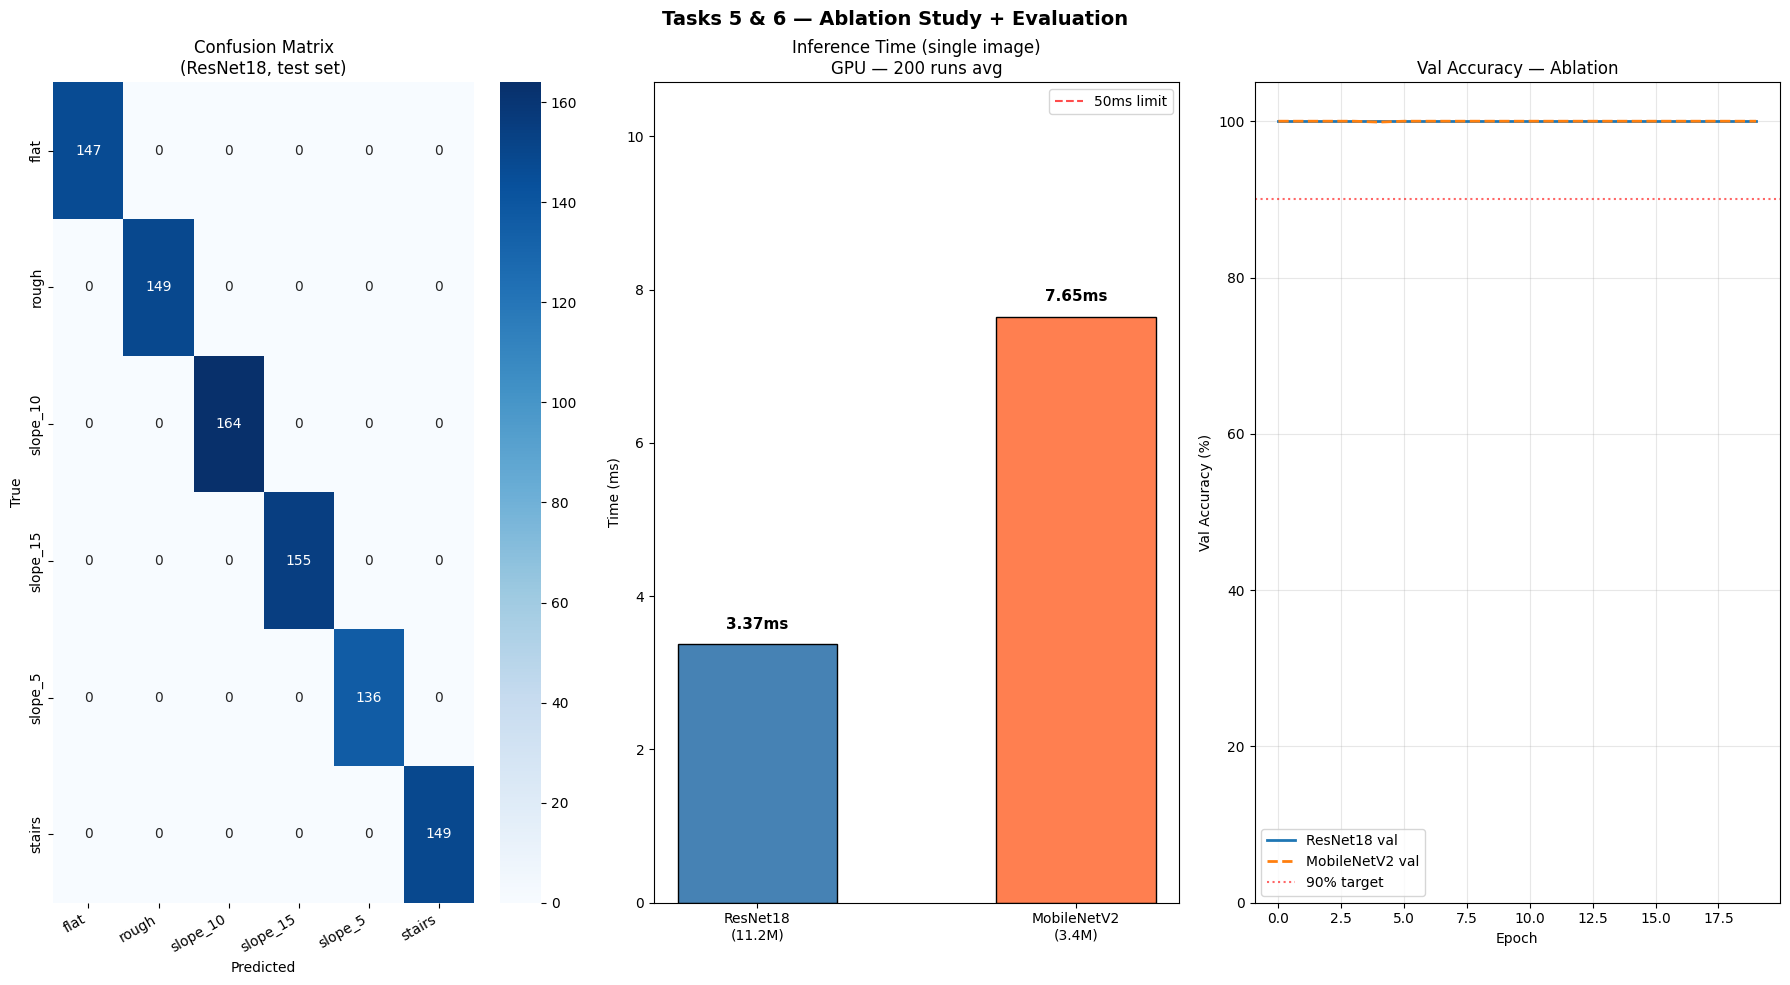

✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/ablation_evaluation.png


In [ ]:
import torch, torch.nn as nn, time, copy
import torchvision.models as models
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Must run after Tasks 3 & 4 (loaders, CLASSES, DEVICE defined) ─────────────
CLASSES = ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']

# ══════════════════════════════════════════════════════════════════════════════
# TASK 5 — Ablation: MobileNetV2 vs ResNet18
# ══════════════════════════════════════════════════════════════════════════════

def build_mobilenetv2(num_classes=6):
    model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
    model.classifier[1] = nn.Linear(1280, num_classes)
    return model.to(DEVICE)

def count_params(model):
    return sum(p.numel() for p in model.parameters())

def measure_inference_time(model, n_runs=200):
    """Average inference time per image on GPU (milliseconds)."""
    model.eval()
    dummy = torch.randn(1, 3, 224, 224).to(DEVICE)
    # Warmup
    with torch.no_grad():
        for _ in range(20):
            _ = model(dummy)
    # Timed runs
    torch.cuda.synchronize()
    t0 = time.perf_counter()
    with torch.no_grad():
        for _ in range(n_runs):
            _ = model(dummy)
    torch.cuda.synchronize()
    return (time.perf_counter() - t0) / n_runs * 1000  # ms

def train_model(model, name, epochs=20):
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4
    )
    best_acc, best_w = 0.0, None
    history = {"train_acc": [], "val_acc": [], "train_loss": [], "val_loss": []}
    t0 = time.time()
    print(f"\nTraining {name}  ({count_params(model):,} params)")
    print(f"{'Ep':>4}  {'T-Acc':>7}  {'V-Acc':>7}")
    for ep in range(1, epochs + 1):
        # Train
        model.train()
        correct, total, run_loss = 0, 0, 0.0
        for imgs, labels in train_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            out  = model(imgs)
            loss = criterion(out, labels)
            loss.backward(); optimizer.step()
            correct  += (out.argmax(1) == labels).sum().item()
            total    += imgs.size(0)
            run_loss += loss.item() * imgs.size(0)
        t_acc  = correct / total
        t_loss = run_loss / total
        # Val
        model.eval()
        vc, vt, vl = 0, 0, 0.0
        with torch.no_grad():
            for imgs, labels in val_loader:
                imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
                out  = model(imgs)
                loss = criterion(out, labels)
                vc  += (out.argmax(1) == labels).sum().item()
                vt  += imgs.size(0); vl += loss.item() * imgs.size(0)
        v_acc  = vc / vt; v_loss = vl / vt
        scheduler.step(v_loss)
        history["train_acc"].append(t_acc); history["val_acc"].append(v_acc)
        history["train_loss"].append(t_loss); history["val_loss"].append(v_loss)
        if v_acc > best_acc:
            best_acc = v_acc; best_w = copy.deepcopy(model.state_dict())
        if ep % 5 == 0 or ep == 1:
            print(f"{ep:>4}  {t_acc:>6.1%}  {v_acc:>6.1%}  [{time.time()-t0:.0f}s]")
    model.load_state_dict(best_w)
    return model, best_acc, history

# Train MobileNetV2
mobilenet = build_mobilenetv2()
mobilenet, mob_val_acc, mob_history = train_model(mobilenet, "MobileNetV2", epochs=20)
torch.save(mobilenet.state_dict(), "/content/drive/MyDrive/PRCV_Final_Project/mobilenetv2_terrain_best.pth")

# Evaluate both on test set
@torch.no_grad()
def test_accuracy(model):
    model.eval()
    correct, total = 0, 0
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        correct += (model(imgs).argmax(1) == labels).sum().item()
        total   += imgs.size(0)
    return correct / total

resnet = build_resnet18()
resnet.load_state_dict(torch.load("/content/drive/MyDrive/PRCV_Final_Project/resnet18_terrain_best.pth"))

res_test_acc = test_accuracy(resnet)
mob_test_acc = test_accuracy(mobilenet)
res_time     = measure_inference_time(resnet)
mob_time     = measure_inference_time(mobilenet)

# ── Ablation comparison table ──────────────────────────────────────────────────
print("\n" + "═"*62)
print(f"{'Model':<16} {'Params':>10} {'Val Acc':>9} {'Test Acc':>9} {'Time(ms)':>9}")
print("─"*62)
print(f"{'ResNet18':<16} {count_params(resnet):>10,} {1.0:>9.2%} {res_test_acc:>9.2%} {res_time:>8.2f}")
print(f"{'MobileNetV2':<16} {count_params(mobilenet):>10,} {mob_val_acc:>9.2%} {mob_test_acc:>9.2%} {mob_time:>8.2f}")
print("═"*62)
print(f"MobileNetV2 speedup: {res_time/mob_time:.1f}x faster | "
      f"param reduction: {(1 - count_params(mobilenet)/count_params(resnet))*100:.0f}% fewer params")

# ══════════════════════════════════════════════════════════════════════════════
# TASK 6 — Full Evaluation on Test Set (best model = ResNet18)
# ══════════════════════════════════════════════════════════════════════════════

@torch.no_grad()
def get_predictions(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    for imgs, labels in loader:
        imgs = imgs.to(DEVICE)
        preds = model(imgs).argmax(1).cpu()
        all_preds.append(preds); all_labels.append(labels)
    return torch.cat(all_preds).numpy(), torch.cat(all_labels).numpy()

preds, labels = get_predictions(resnet, test_loader)

# Classification report
print("\nClassification Report — ResNet18 (test set):")
print(classification_report(labels, preds, target_names=CLASSES, digits=3))

# ── Plots ──────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))

# 1. Confusion matrix
ax1 = fig.add_subplot(1, 3, 1)
cm  = confusion_matrix(labels, preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASSES, yticklabels=CLASSES, ax=ax1)
ax1.set_title("Confusion Matrix\n(ResNet18, test set)", fontsize=12)
ax1.set_xlabel("Predicted"); ax1.set_ylabel("True")
plt.setp(ax1.get_xticklabels(), rotation=30, ha='right')

# 2. Inference time bar chart
ax2 = fig.add_subplot(1, 3, 2)
models_names = ["ResNet18\n(11.2M)", "MobileNetV2\n(3.4M)"]
times        = [res_time, mob_time]
colors       = ['steelblue', 'coral']
bars = ax2.bar(models_names, times, color=colors, edgecolor='black', width=0.5)
ax2.axhline(y=50, color='red', linestyle='--', alpha=0.7, label='50ms limit')
for bar, t in zip(bars, times):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
             f'{t:.2f}ms', ha='center', fontsize=11, fontweight='bold')
ax2.set_title("Inference Time (single image)\nGPU — 200 runs avg", fontsize=12)
ax2.set_ylabel("Time (ms)"); ax2.legend(); ax2.set_ylim(0, max(times)*1.4)

# 3. Training curves comparison
ax3 = fig.add_subplot(1, 3, 3)
# Load ResNet18 history from Task 4 (use history dict if still in scope)
try:
    ax3.plot([a*100 for a in history["val_acc"][:20]], label="ResNet18 val", linewidth=2)
except NameError:
    pass
ax3.plot([a*100 for a in mob_history["val_acc"]], label="MobileNetV2 val",
         linewidth=2, linestyle='--')
ax3.axhline(y=90, color='red', linestyle=':', alpha=0.6, label='90% target')
ax3.set_title("Val Accuracy — Ablation", fontsize=12)
ax3.set_xlabel("Epoch"); ax3.set_ylabel("Val Accuracy (%)")
ax3.set_ylim(0, 105); ax3.legend(); ax3.grid(True, alpha=0.3)

plt.suptitle("Tasks 5 & 6 — Ablation Study + Evaluation", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/ablation_evaluation.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: /content/drive/MyDrive/PRCV_Final_Project/ablation_evaluation.png")

✅ Classifier loaded
✅ flat         — 300 frames in 109.1s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/flat_demo.mp4
✅ rough        — 300 frames in 115.8s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/rough_demo.mp4
✅ slope_10     — 300 frames in 106.9s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/slope_10_demo.mp4
✅ slope_15     — 300 frames in 104.5s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/slope_15_demo.mp4
✅ slope_5      — 300 frames in 108.1s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/slope_5_demo.mp4
✅ stairs       — 300 frames in 115.7s → /content/drive/MyDrive/PRCV_Final_Project/demo_videos/stairs_demo.mp4

✅ All demo videos saved to /content/drive/MyDrive/PRCV_Final_Project/demo_videos/

Generating static summary figure...


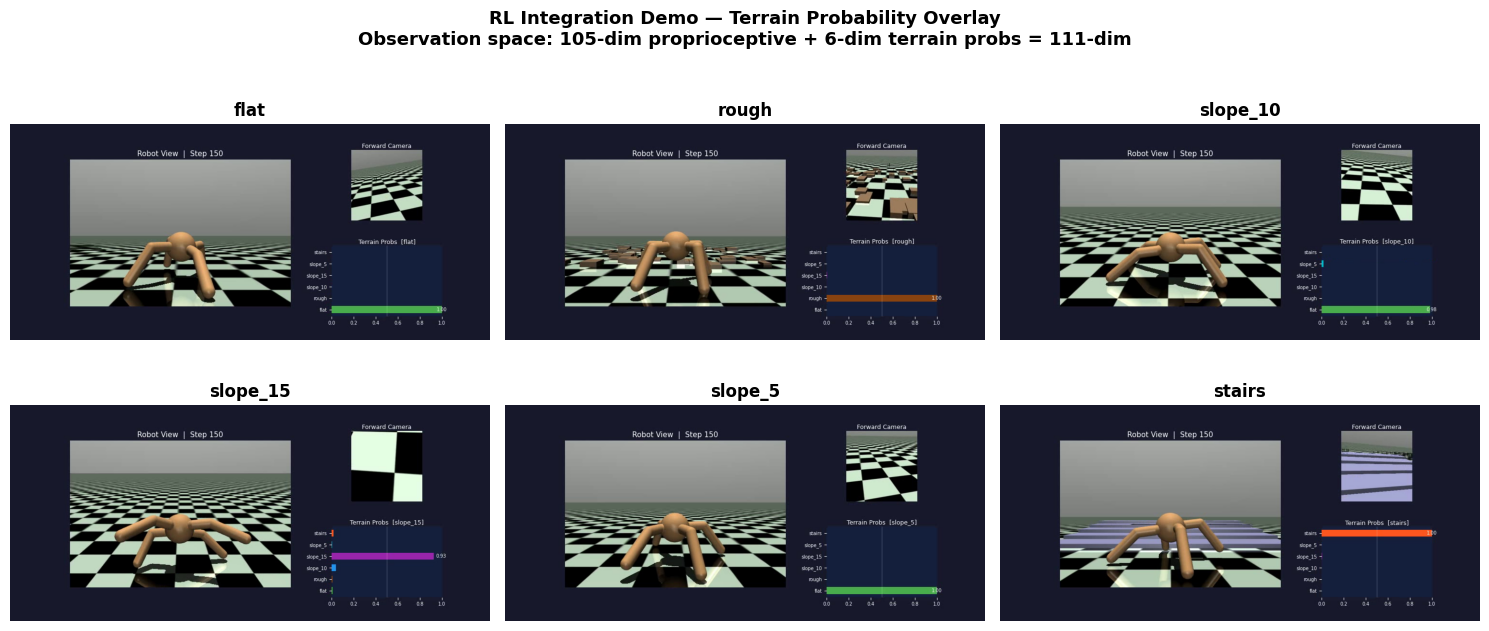

✅ Integration summary saved to /content/drive/MyDrive/PRCV_Final_Project/integration_summary.png

  Observation space extension:
  Proprioceptive only  : 105 dimensions
  + Terrain classifier :   6 dimensions (probabilities)
  Vision-Enhanced total: 111 dimensions


In [ ]:
import os, time, cv2, torch, torch.nn as nn
import numpy as np
import gymnasium as gym
import torchvision.models as models
import torchvision.transforms as transforms
import mujoco
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

os.environ["MUJOCO_GL"] = "egl"

# ── Config ─────────────────────────────────────────────────────────────────────
CLASSES    = ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']
DEVICE     = torch.device("cuda" if torch.cuda.is_available() else "cpu")
N_STEPS    = 300       # frames to record per terrain
VIDEO_FPS  = 30
BAR_COLORS = ['#4CAF50','#8B4513','#2196F3','#9C27B0','#00BCD4','#FF5722']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Load trained ResNet18 classifier ──────────────────────────────────────────
def load_classifier(ckpt="/content/drive/MyDrive/PRCV_Final_Project/resnet18_terrain_best.pth"):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, len(CLASSES))
    model.load_state_dict(torch.load(ckpt, map_location=DEVICE))
    model.to(DEVICE).eval()
    return model

classifier = load_classifier()
print("✅ Classifier loaded")

# ── Inference transform (no augmentation) ────────────────────────────────────
infer_transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

@torch.no_grad()
def classify_frame(frame_rgb):
    """frame_rgb: H×W×3 uint8 numpy array → terrain probabilities (6,)"""
    x = infer_transform(frame_rgb).unsqueeze(0).to(DEVICE)
    return torch.softmax(classifier(x), dim=1).squeeze().cpu().numpy()

# ── VisionEnhancedAnt wrapper ─────────────────────────────────────────────────
class VisionEnhancedAnt:
    """
    Wraps a MuJoCo terrain environment with the forward camera classifier.
    Extends the 105-dim proprioceptive observation to 111-dim by appending
    6 terrain probability scores from the CNN classifier.
    Also exposes get_camera_frame() for visualization.
    """
    def __init__(self, xml_path, classifier_fn):
        with open(xml_path) as f:
            xml = f.read()
        self.model      = mujoco.MjModel.from_xml_string(xml)
        self.data       = mujoco.MjData(self.model)
        self.renderer   = mujoco.Renderer(self.model, height=224, width=224)
        self.renderer3p = mujoco.Renderer(self.model, height=320, width=480)
        self.classify   = classifier_fn
        self.INIT_QPOS  = [0,0,0.55,1,0,0,0, 0,1,0,-1,0,-1,0,1]

    def reset(self):
        mujoco.mj_resetData(self.model, self.data)
        self.data.qpos[:len(self.INIT_QPOS)] = self.INIT_QPOS
        mujoco.mj_forward(self.model, self.data)
        return self._get_augmented_obs()

    def step(self, action=None):
        """Apply random action and step physics."""
        if action is None:
            action = np.random.uniform(-0.3, 0.3, 8)
        self.data.ctrl[:] = action
        mujoco.mj_step(self.model, self.data)
        return self._get_augmented_obs()

    def _get_augmented_obs(self):
        # Proprioceptive obs (simplified: qpos + qvel → 29 dims here, full=105)
        prop_obs   = np.concatenate([self.data.qpos, self.data.qvel])
        cam_frame  = self._get_camera_frame()
        terrain_p  = self.classify(cam_frame)
        return np.concatenate([prop_obs, terrain_p]), terrain_p, cam_frame

    def _get_camera_frame(self):
        self.renderer.update_scene(self.data, camera="forward_cam")
        return self.renderer.render().copy()

    def get_third_person_frame(self):
        self.renderer3p.update_scene(self.data, camera="track")
        return self.renderer3p.render().copy()

    def close(self):
        self.renderer.close()
        self.renderer3p.close()

# ── Overlay builder ────────────────────────────────────────────────────────────
def build_overlay_frame(third_person, cam_frame, probs, terrain_name, step_n):
    """
    Combines:
      - Third-person view (main panel, left)
      - Forward camera view (top-right inset)
      - Probability bar chart (bottom-right)
    Returns a single H×W×3 uint8 frame.
    """
    fig = plt.figure(figsize=(10, 4.5), dpi=100)
    fig.patch.set_facecolor('#1a1a2e')
    gs  = GridSpec(2, 2, figure=fig, width_ratios=[2, 1], hspace=0.35, wspace=0.25)

    # Left: third-person view
    ax_main = fig.add_subplot(gs[:, 0])
    ax_main.imshow(third_person)
    ax_main.set_title(f"Robot View  |  Step {step_n}", color='white', fontsize=11, pad=5)
    ax_main.axis('off')

    # Top-right: forward camera
    ax_cam = fig.add_subplot(gs[0, 1])
    ax_cam.imshow(cam_frame)
    ax_cam.set_title("Forward Camera", color='white', fontsize=9, pad=3)
    ax_cam.axis('off')

    # Bottom-right: probability bars
    ax_bar = fig.add_subplot(gs[1, 1])
    ax_bar.set_facecolor('#16213e')
    bars = ax_bar.barh(CLASSES, probs, color=BAR_COLORS, edgecolor='none', height=0.6)
    ax_bar.set_xlim(0, 1)
    ax_bar.axvline(x=0.5, color='white', linewidth=0.5, alpha=0.4)
    for bar, p in zip(bars, probs):
        if p > 0.05:
            ax_bar.text(min(p + 0.02, 0.95), bar.get_y() + bar.get_height()/2,
                       f'{p:.2f}', va='center', color='white', fontsize=7)
    ax_bar.set_title(f"Terrain Probs  [{terrain_name}]",
                     color='white', fontsize=9, pad=3)
    ax_bar.tick_params(colors='white', labelsize=7)
    ax_bar.spines[:].set_visible(False)
    for label in ax_bar.get_yticklabels():
        label.set_color('white')

    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    frame = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    frame = frame[:, :, :3].copy()   # drop alpha → RGB
    plt.close(fig)
    return frame

# ── Record demo video for each terrain ────────────────────────────────────────
os.makedirs("/content/drive/MyDrive/PRCV_Final_Project/demo_videos", exist_ok=True)
video_paths = []

for terrain in CLASSES:
    xml_path = f"/content/drive/MyDrive/PRCV_Final_Project/envs/{terrain}.xml"
    env      = VisionEnhancedAnt(xml_path, classify_frame)
    env.reset()

    out_path = f"/content/drive/MyDrive/PRCV_Final_Project/demo_videos/{terrain}_demo.mp4"
    # Get frame size from first overlay
    tp    = env.get_third_person_frame()
    cam   = env._get_camera_frame()
    probs = classify_frame(cam)
    test_frame = build_overlay_frame(tp, cam, probs, terrain, 0)
    h, w  = test_frame.shape[:2]

    writer = cv2.VideoWriter(out_path,
                             cv2.VideoWriter_fourcc(*'mp4v'),
                             VIDEO_FPS, (w, h))
    t0 = time.time()
    for step in range(N_Steps := N_STEPS):
        obs, probs, cam_frame = env.step()
        tp_frame = env.get_third_person_frame()
        overlay  = build_overlay_frame(tp_frame, cam_frame, probs, terrain, step)
        writer.write(cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    writer.release()
    env.close()
    elapsed = time.time() - t0
    print(f"✅ {terrain:12s} — {N_Steps} frames in {elapsed:.1f}s → {out_path}")
    video_paths.append(out_path)

print(f"\n✅ All demo videos saved to /content/drive/MyDrive/PRCV_Final_Project/demo_videos/")

# ── Static summary: show one frame per terrain ────────────────────────────────
print("\nGenerating static summary figure...")
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, terrain in zip(axes.flatten(), CLASSES):
    # Grab single representative frame from each video
    cap   = cv2.VideoCapture(f"/content/drive/MyDrive/PRCV_Final_Project/demo_videos/{terrain}_demo.mp4")
    cap.set(cv2.CAP_PROP_POS_FRAMES, N_STEPS // 2)   # middle frame
    ret, frame = cap.read(); cap.release()
    if ret:
        ax.imshow(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
    ax.set_title(terrain, fontsize=12, fontweight='bold')
    ax.axis('off')

plt.suptitle("RL Integration Demo — Terrain Probability Overlay\n"
             "Observation space: 105-dim proprioceptive + 6-dim terrain probs = 111-dim",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/integration_summary.png", dpi=120, bbox_inches='tight')
plt.show()
print("✅ Integration summary saved to /content/drive/MyDrive/PRCV_Final_Project/integration_summary.png")
print("\n" + "="*55)
print("  Observation space extension:")
print("  Proprioceptive only  : 105 dimensions")
print("  + Terrain classifier :   6 dimensions (probabilities)")
print("  Vision-Enhanced total: 111 dimensions")
print("="*55)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


✅ ResNet18 loaded from Drive checkpoint

Loading real-world images:
  flat      : 20 images found
  rough     : 20 images found
  stairs    : 20 images found

Total: 60 images loaded

═════════════════════════════════════════════
  SIM-TO-REAL BASELINE RESULTS
═════════════════════════════════════════════
  Overall accuracy: 55.0%  (33/60)

  flat      : 0.0%  (0/20)
  rough     : 65.0%  (13/20)
  stairs    : 100.0%  (20/20)
═════════════════════════════════════════════

Prediction breakdown (all classes predicted):
Counter({'stairs': 23, 'slope_15': 17, 'rough': 17, 'slope_10': 3})


/tmp/ipykernel_17496/3896474112.py:154: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17496/3896474112.py:154: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_17496/3896474112.py:155: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/simtoreal_baseline.png",
/tmp/ipykernel_17496/3896474112.py:155: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/simtoreal_baseline.png",
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK 

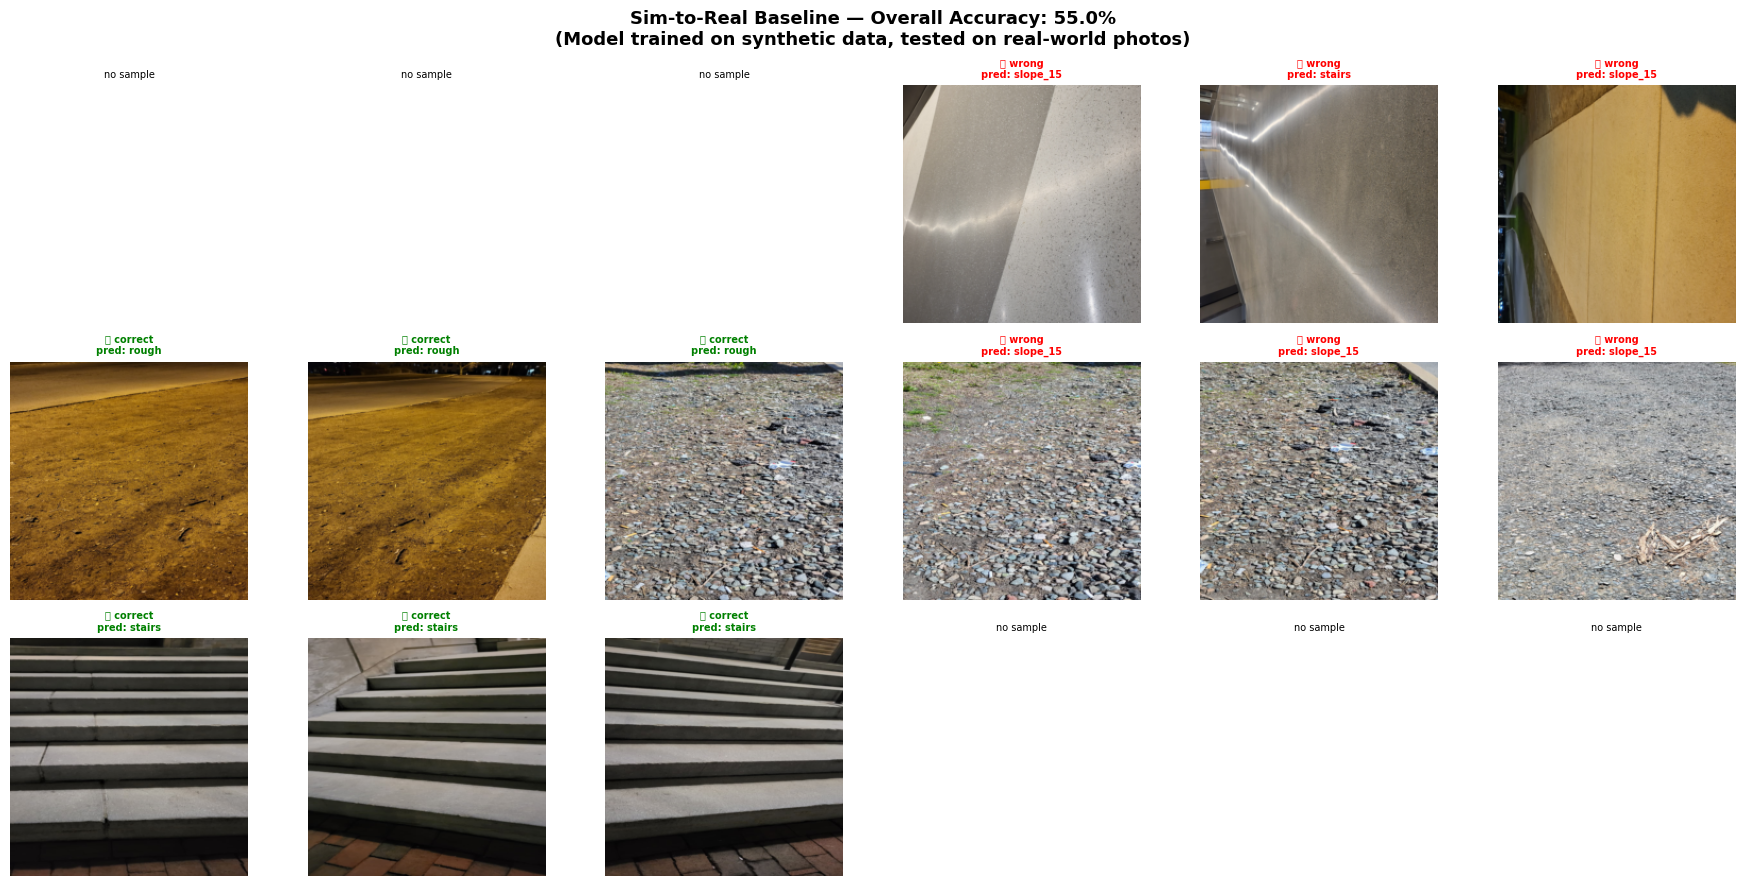

✅ Saved: simtoreal_baseline.png


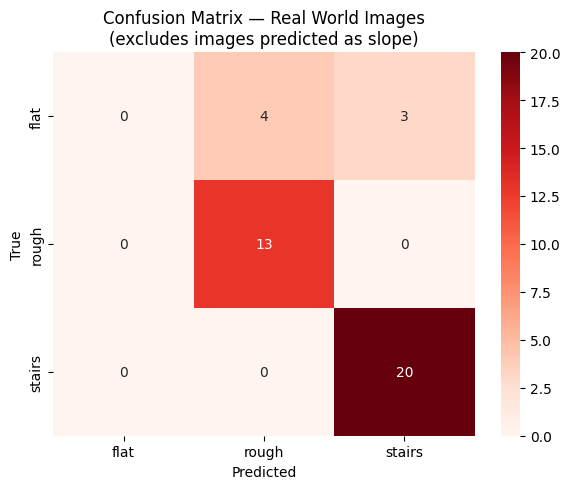

✅ Saved: simtoreal_confusion.png


In [ ]:
import os, torch, torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# ── Config ─────────────────────────────────────────────────────────────────────
DEVICE       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
REAL_DIR     = "/content/drive/MyDrive/PRCV_Final_Project/real_world_images"
CKPT         = "/content/drive/MyDrive/PRCV_Final_Project/resnet18_terrain_best.pth"

# Only 3 real-world classes — must match folder names
REAL_CLASSES    = ['flat', 'rough', 'stairs']
# Their indices in the original 6-class model
# Original order: ['flat','rough','slope_10','slope_15','slope_5','stairs']
REAL_CLASS_IDX  = [0, 1, 5]   # flat=0, rough=1, stairs=5
ALL_CLASSES     = ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Load model ─────────────────────────────────────────────────────────────────
def load_model(ckpt_path):
    model = models.resnet18(weights=None)
    model.fc = nn.Linear(512, 6)
    model.load_state_dict(torch.load(ckpt_path, map_location=DEVICE))
    return model.to(DEVICE).eval()

model = load_model(CKPT)
print("✅ ResNet18 loaded from Drive checkpoint")

# ── Transform (same as eval — no augmentation) ────────────────────────────────
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Load real-world images ─────────────────────────────────────────────────────
def load_real_images(root, classes):
    images, labels, paths = [], [], []
    for cls in classes:
        cls_dir = os.path.join(root, cls)
        files   = [f for f in os.listdir(cls_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png','.heic','.webp'))]
        print(f"  {cls:10s}: {len(files)} images found")
        for f in files:
            p = os.path.join(cls_dir, f)
            try:
                img = Image.open(p).convert('RGB')
                images.append(transform(img))
                labels.append(classes.index(cls))
                paths.append(p)
            except Exception as e:
                print(f"    ⚠️  Could not load {f}: {e}")
    return torch.stack(images), torch.tensor(labels), paths

print("\nLoading real-world images:")
imgs, labels, paths = load_real_images(REAL_DIR, REAL_CLASSES)
print(f"\nTotal: {len(imgs)} images loaded")

# ── Run inference ──────────────────────────────────────────────────────────────
@torch.no_grad()
def predict(model, imgs, batch_size=16):
    all_preds, all_probs = [], []
    for i in range(0, len(imgs), batch_size):
        batch  = imgs[i:i+batch_size].to(DEVICE)
        logits = model(batch)
        probs  = torch.softmax(logits, dim=1).cpu()
        preds  = logits.argmax(dim=1).cpu()
        all_preds.append(preds)
        all_probs.append(probs)
    return torch.cat(all_preds), torch.cat(all_probs)

preds_6class, probs = predict(model, imgs)

# Map 6-class predictions back to 3-class for evaluation
# Any prediction NOT in [flat, rough, stairs] counts as wrong
def map_pred(pred_idx):
    name = ALL_CLASSES[pred_idx]
    if name in REAL_CLASSES:
        return REAL_CLASSES.index(name)
    return -1   # predicted a slope class → wrong

preds_mapped = torch.tensor([map_pred(p.item()) for p in preds_6class])

# ── Per-class accuracy ─────────────────────────────────────────────────────────
print("\n" + "═"*45)
print("  SIM-TO-REAL BASELINE RESULTS")
print("═"*45)
overall_correct = (preds_mapped == labels).sum().item()
overall_acc     = overall_correct / len(labels)
print(f"  Overall accuracy: {overall_acc:.1%}  ({overall_correct}/{len(labels)})")
print()

per_class_acc = {}
for i, cls in enumerate(REAL_CLASSES):
    mask    = labels == i
    correct = (preds_mapped[mask] == labels[mask]).sum().item()
    total   = mask.sum().item()
    acc     = correct / total if total > 0 else 0
    per_class_acc[cls] = acc
    print(f"  {cls:10s}: {acc:.1%}  ({correct}/{total})")
print("═"*45)

# What did the model predict when it was wrong?
print("\nPrediction breakdown (all classes predicted):")
from collections import Counter
pred_names = [ALL_CLASSES[p.item()] for p in preds_6class]
print(Counter(pred_names))

# ── Visualize: correct vs incorrect examples ───────────────────────────────────
mean = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std  = torch.tensor(IMAGENET_STD).view(3,1,1)

def denorm(t):
    return (t * std + mean).clamp(0,1).permute(1,2,0).numpy()

fig, axes = plt.subplots(3, 6, figsize=(18, 9))
for cls_idx, cls in enumerate(REAL_CLASSES):
    cls_mask    = (labels == cls_idx).nonzero().squeeze(1)
    correct_idx = [i for i in cls_mask if preds_mapped[i] == cls_idx]
    wrong_idx   = [i for i in cls_mask if preds_mapped[i] != cls_idx]

    # Show 3 correct + 3 wrong per class
    for col, idx_list, tag, color in [
        (0, correct_idx, "✅ correct", 'green'),
        (3, wrong_idx,   "❌ wrong",   'red')
    ]:
        for offset in range(3):
            ax = axes[cls_idx][col + offset]
            if offset < len(idx_list):
                i     = idx_list[offset]
                img   = denorm(imgs[i])
                pred  = ALL_CLASSES[preds_6class[i].item()]
                ax.imshow(img)
                ax.set_title(f"{tag}\npred: {pred}", fontsize=7,
                             color=color, fontweight='bold')
            else:
                ax.imshow(np.ones((224,224,3)))
                ax.set_title("no sample", fontsize=7)
            ax.axis('off')

    axes[cls_idx][0].set_ylabel(cls.upper(), fontsize=11,
                                 fontweight='bold', rotation=90, labelpad=10)

plt.suptitle(f"Sim-to-Real Baseline — Overall Accuracy: {overall_acc:.1%}\n"
             f"(Model trained on synthetic data, tested on real-world photos)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/simtoreal_baseline.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("✅ Saved: simtoreal_baseline.png")

# ── Confusion matrix (3-class, exclude slope predictions) ─────────────────────
valid_mask = preds_mapped != -1
if valid_mask.sum() > 0:
    fig2, ax = plt.subplots(figsize=(6,5))
    cm = confusion_matrix(labels[valid_mask], preds_mapped[valid_mask])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
                xticklabels=REAL_CLASSES,
                yticklabels=REAL_CLASSES, ax=ax)
    ax.set_title("Confusion Matrix — Real World Images\n(excludes images predicted as slope)")
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    plt.tight_layout()
    plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/simtoreal_confusion.png",
                dpi=120, bbox_inches='tight')
    plt.show()
    print("✅ Saved: simtoreal_confusion.png")

✅ Domain randomization DataLoaders ready
   Train: 4200 | Val: 900


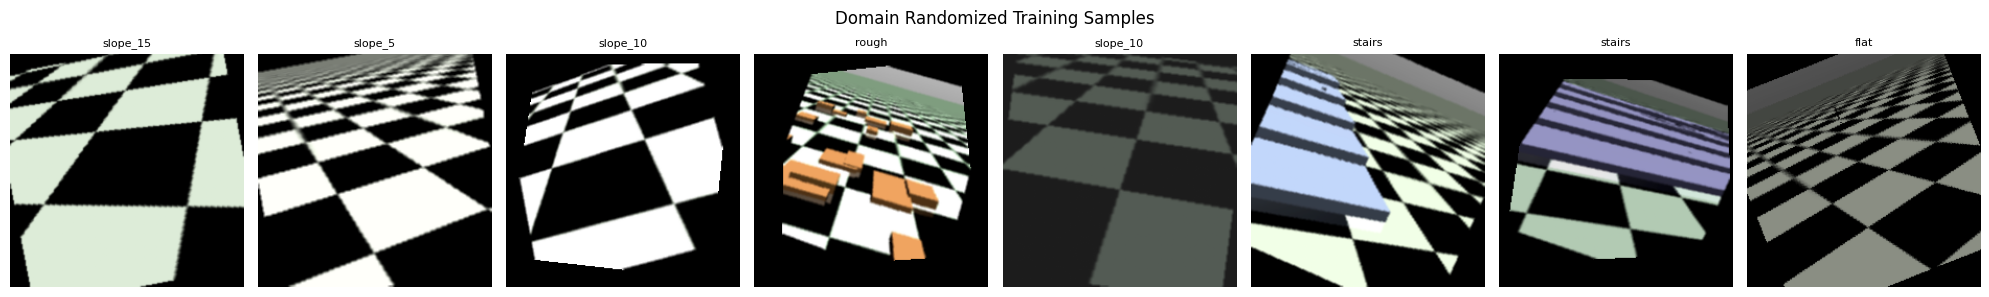

✅ Domain randomization samples saved

Retraining with domain randomization (25 epochs)...
  Ep    T-Acc    V-Acc
   1   95.4%  100.0%  [62s]
   5   99.8%  100.0%  [318s]
  10   99.7%  100.0%  [635s]
  15  100.0%  100.0%  [949s]
  20  100.0%  100.0%  [1272s]
  25  100.0%  100.0%  [1587s]

✅ Domain randomization model saved  (best val acc: 100.00%)

══════════════════════════════════════════════════
  DOMAIN RANDOMIZATION — REAL WORLD RESULTS
══════════════════════════════════════════════════
  Overall accuracy: 66.7%  vs baseline 55.0%

  flat      : 0.0%  (0/20)
  rough     : 100.0%  (20/20)
  stairs    : 100.0%  (20/20)
══════════════════════════════════════════════════


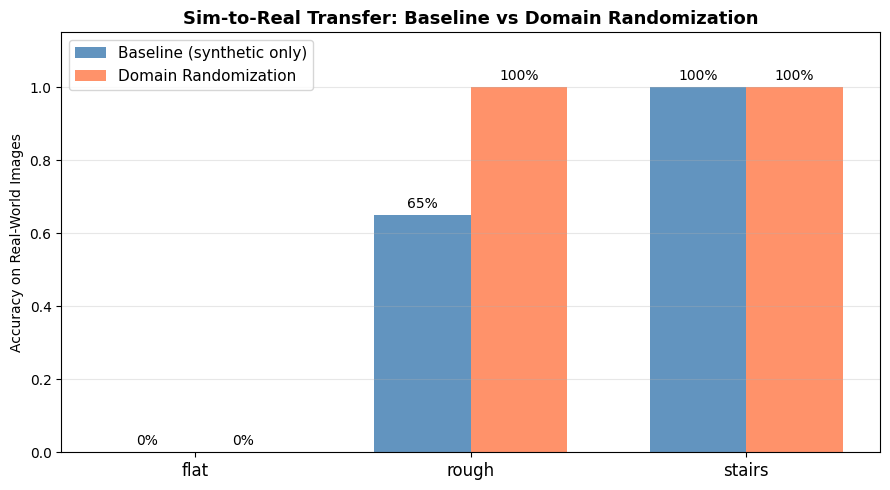

✅ Comparison chart saved


In [ ]:
import torch, torch.nn as nn, time, copy
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# ── Must run after Task 3 (train_loader, val_loader, test_loader defined) ──────
DEVICE      = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ALL_CLASSES = ['flat', 'rough', 'slope_10', 'slope_15', 'slope_5', 'stairs']
REAL_CLASSES = ['flat', 'rough', 'stairs']

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# ── Domain Randomization Transform ────────────────────────────────────────────
# Much more aggressive augmentation than before — simulates real-world variation:
# - Strong lighting changes (brightness/contrast/saturation)
# - Random grayscale (removes color dependency)
# - Gaussian blur (simulates camera focus variation)
# - Random perspective (simulates different camera angles)
# - Stronger rotation
domain_rand_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=25),
    transforms.ColorJitter(brightness=0.6, contrast=0.6,
                           saturation=0.5, hue=0.1),
    transforms.RandomGrayscale(p=0.15),
    transforms.GaussianBlur(kernel_size=3, sigma=(0.1, 2.0)),
    transforms.RandomPerspective(distortion_scale=0.3, p=0.5),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

# ── Rebuild DataLoader with domain randomization ───────────────────────────────
from torchvision import datasets
from torch.utils.data import DataLoader, Subset, random_split

DATA_DIR = "/content/drive/MyDrive/PRCV_Final_Project/data"
SEED, BATCH_SIZE = 42, 32

torch.manual_seed(SEED)
full_ds  = datasets.ImageFolder(root=DATA_DIR)
n        = len(full_ds)
n_train  = int(0.70 * n)
n_val    = int(0.15 * n)
n_test   = n - n_train - n_val

train_idx, val_idx, test_idx = random_split(
    range(n), [n_train, n_val, n_test],
    generator=torch.Generator().manual_seed(SEED)
)

# Training uses domain randomization, val/test use standard eval transform
eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

dr_train_ds = Subset(datasets.ImageFolder(DATA_DIR, transform=domain_rand_transform),
                     train_idx.indices)
dr_val_ds   = Subset(datasets.ImageFolder(DATA_DIR, transform=eval_transform),
                     val_idx.indices)

dr_train_loader = DataLoader(dr_train_ds, batch_size=BATCH_SIZE,
                              shuffle=True, num_workers=2, pin_memory=True)
dr_val_loader   = DataLoader(dr_val_ds,   batch_size=BATCH_SIZE,
                              shuffle=False, num_workers=2, pin_memory=True)

print("✅ Domain randomization DataLoaders ready")
print(f"   Train: {len(dr_train_ds)} | Val: {len(dr_val_ds)}")

# ── Visualize domain randomized samples ───────────────────────────────────────
mean_t = torch.tensor(IMAGENET_MEAN).view(3,1,1)
std_t  = torch.tensor(IMAGENET_STD).view(3,1,1)

imgs_sample, lbls_sample = next(iter(dr_train_loader))
imgs_disp = (imgs_sample[:8] * std_t + mean_t).clamp(0,1).permute(0,2,3,1).numpy()

fig, axes = plt.subplots(1, 8, figsize=(20, 3))
for ax, img, lbl in zip(axes, imgs_disp, lbls_sample[:8]):
    ax.imshow(img)
    ax.set_title(ALL_CLASSES[lbl], fontsize=8)
    ax.axis('off')
plt.suptitle("Domain Randomized Training Samples", fontsize=12)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/domain_rand_samples.png",
            dpi=100, bbox_inches='tight')
plt.show()
print("✅ Domain randomization samples saved")

# ── Retrain ResNet18 with domain randomization ─────────────────────────────────
def build_resnet18():
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(512, 6)
    return model.to(DEVICE)

dr_model   = build_resnet18()
criterion  = nn.CrossEntropyLoss()
optimizer  = torch.optim.Adam(dr_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler  = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min', factor=0.5, patience=4)

best_acc, best_w = 0.0, None
history = {"train_acc": [], "val_acc": []}
NUM_EPOCHS = 25

print(f"\nRetraining with domain randomization ({NUM_EPOCHS} epochs)...")
print(f"{'Ep':>4}  {'T-Acc':>7}  {'V-Acc':>7}")

t0 = time.time()
for ep in range(1, NUM_EPOCHS + 1):
    # Train
    dr_model.train()
    correct, total, run_loss = 0, 0, 0.0
    for imgs, labels in dr_train_loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        out  = dr_model(imgs)
        loss = criterion(out, labels)
        loss.backward(); optimizer.step()
        correct  += (out.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        run_loss += loss.item() * imgs.size(0)
    t_acc = correct / total

    # Val
    dr_model.eval()
    vc, vt, vl = 0, 0, 0.0
    with torch.no_grad():
        for imgs, labels in dr_val_loader:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = dr_model(imgs)
            loss = criterion(out, labels)
            vc  += (out.argmax(1) == labels).sum().item()
            vt  += imgs.size(0); vl += loss.item() * imgs.size(0)
    v_acc = vc / vt
    scheduler.step(vl / vt)

    history["train_acc"].append(t_acc)
    history["val_acc"].append(v_acc)

    if v_acc > best_acc:
        best_acc = v_acc
        best_w   = copy.deepcopy(dr_model.state_dict())

    if ep % 5 == 0 or ep == 1:
        print(f"{ep:>4}  {t_acc:>6.1%}  {v_acc:>6.1%}  [{time.time()-t0:.0f}s]")

dr_model.load_state_dict(best_w)
torch.save(best_w,
    "/content/drive/MyDrive/PRCV_Final_Project/resnet18_domain_rand.pth")
print(f"\n✅ Domain randomization model saved  (best val acc: {best_acc:.2%})")

# ── Re-evaluate on real-world images ──────────────────────────────────────────
from PIL import Image
import numpy as np

def load_real_images_eval(root, classes):
    images, labels, paths = [], [], []
    for cls in classes:
        cls_dir = os.path.join(root, cls)
        files   = [f for f in os.listdir(cls_dir)
                   if f.lower().endswith(('.jpg','.jpeg','.png','.heic','.webp'))]
        for f in files:
            p = os.path.join(cls_dir, f)
            try:
                img = Image.open(p).convert('RGB')
                images.append(eval_transform(img))
                labels.append(classes.index(cls))
                paths.append(p)
            except: pass
    return torch.stack(images), torch.tensor(labels)

REAL_DIR = "/content/drive/MyDrive/PRCV_Final_Project/real_world_images"
imgs_real, labels_real = load_real_images_eval(REAL_DIR, REAL_CLASSES)

def map_pred(pred_idx):
    name = ALL_CLASSES[pred_idx]
    return REAL_CLASSES.index(name) if name in REAL_CLASSES else -1

@torch.no_grad()
def predict_model(model, imgs):
    model.eval()
    all_preds, all_probs = [], []
    for i in range(0, len(imgs), 16):
        batch  = imgs[i:i+16].to(DEVICE)
        logits = model(batch)
        all_preds.append(logits.argmax(1).cpu())
        all_probs.append(torch.softmax(logits, dim=1).cpu())
    return torch.cat(all_preds), torch.cat(all_probs)

preds_dr, _ = predict_model(dr_model, imgs_real)
preds_dr_mapped = torch.tensor([map_pred(p.item()) for p in preds_dr])

print("\n" + "═"*50)
print("  DOMAIN RANDOMIZATION — REAL WORLD RESULTS")
print("═"*50)
dr_overall = (preds_dr_mapped == labels_real).sum().item() / len(labels_real)
print(f"  Overall accuracy: {dr_overall:.1%}  vs baseline 55.0%")
print()
for i, cls in enumerate(REAL_CLASSES):
    mask    = labels_real == i
    correct = (preds_dr_mapped[mask] == labels_real[mask]).sum().item()
    total   = mask.sum().item()
    print(f"  {cls:10s}: {correct/total:.1%}  ({correct}/{total})")
print("═"*50)

# ── Comparison bar chart: Baseline vs Domain Randomization ────────────────────
baseline_accs = {'flat': 0.0, 'rough': 0.65, 'stairs': 1.0}
dr_accs = {}
for i, cls in enumerate(REAL_CLASSES):
    mask = labels_real == i
    dr_accs[cls] = (preds_dr_mapped[mask] == labels_real[mask]).sum().item() / mask.sum().item()

x      = np.arange(len(REAL_CLASSES))
width  = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar(x - width/2, [baseline_accs[c] for c in REAL_CLASSES],
               width, label='Baseline (synthetic only)', color='steelblue', alpha=0.85)
bars2 = ax.bar(x + width/2, [dr_accs[c] for c in REAL_CLASSES],
               width, label='Domain Randomization', color='coral', alpha=0.85)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', fontsize=10)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{bar.get_height():.0%}', ha='center', fontsize=10)

ax.set_ylabel("Accuracy on Real-World Images")
ax.set_title("Sim-to-Real Transfer: Baseline vs Domain Randomization",
             fontsize=13, fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(REAL_CLASSES, fontsize=12)
ax.set_ylim(0, 1.15)
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/PRCV_Final_Project/simtoreal_comparison.png",
            dpi=120, bbox_inches='tight')
plt.show()
print("✅ Comparison chart saved")

In [ ]:
import cv2
import numpy as np
import os

# ── Config ─────────────────────────────────────────────────────────────────────
VIDEO_DIR   = "/content/drive/MyDrive/PRCV_Final_Project/demo_videos"
OUTPUT_PATH = "/content/drive/MyDrive/PRCV_Final_Project/demo_grid_combined.mp4"
TERRAIN_ORDER = ["flat", "rough", "slope_10", "slope_15", "slope_5", "stairs"]
FPS         = 30
CELL_W      = 480   # width of each individual video cell
CELL_H      = 320   # height of each individual video cell
GRID_COLS   = 3
GRID_ROWS   = 2
LABEL_H     = 36    # height of label bar above each cell

# Font settings
FONT       = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.75
FONT_COLOR = (255, 255, 255)
FONT_THICK = 2
LABEL_BG   = (30, 30, 60)   # dark blue label background

# ── Open all video captures ────────────────────────────────────────────────────
caps = {}
for terrain in TERRAIN_ORDER:
    path = os.path.join(VIDEO_DIR, f"{terrain}_demo.mp4")
    cap  = cv2.VideoCapture(path)
    if not cap.isOpened():
        print(f"⚠️  Could not open: {path}")
    else:
        caps[terrain] = cap
        total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        print(f"✅ {terrain:12s} — {total} frames")

# ── Total frames = minimum across all videos ──────────────────────────────────
n_frames = min(int(c.get(cv2.CAP_PROP_FRAME_COUNT)) for c in caps.values())
print(f"\nRendering {n_frames} frames at {FPS} FPS...")

# ── Output video writer ────────────────────────────────────────────────────────
FULL_W = CELL_W * GRID_COLS
FULL_H = (CELL_H + LABEL_H) * GRID_ROWS

fourcc = cv2.VideoWriter_fourcc(*'mp4v')
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (FULL_W, FULL_H))

# ── Frame loop ─────────────────────────────────────────────────────────────────
for frame_idx in range(n_frames):
    grid_rows = []

    for row in range(GRID_ROWS):
        row_frames = []
        for col in range(GRID_COLS):
            terrain = TERRAIN_ORDER[row * GRID_COLS + col]
            cap     = caps[terrain]

            ret, frame = cap.read()
            if not ret:
                frame = np.zeros((CELL_H, CELL_W, 3), dtype=np.uint8)
            else:
                frame = cv2.resize(frame, (CELL_W, CELL_H))

            # Label bar above each cell
            label_bar = np.full((LABEL_H, CELL_W, 3), LABEL_BG, dtype=np.uint8)
            label     = terrain.replace('_', ' ').upper()
            text_size = cv2.getTextSize(label, FONT, FONT_SCALE, FONT_THICK)[0]
            tx        = (CELL_W - text_size[0]) // 2
            ty        = (LABEL_H + text_size[1]) // 2
            cv2.putText(label_bar, label, (tx, ty),
                        FONT, FONT_SCALE, FONT_COLOR, FONT_THICK, cv2.LINE_AA)

            # Add thin colored border around each cell
            cv2.rectangle(frame, (0,0), (CELL_W-1, CELL_H-1),
                          (79, 195, 247), 2)   # light blue border

            # Stack label + frame vertically
            cell = np.vstack([label_bar, frame])
            row_frames.append(cell)

        grid_rows.append(np.hstack(row_frames))

    full_frame = np.vstack(grid_rows)
    writer.write(full_frame)

    if frame_idx % 60 == 0:
        print(f"  Frame {frame_idx}/{n_frames}  ({frame_idx/n_frames*100:.0f}%)")

# ── Cleanup ────────────────────────────────────────────────────────────────────
for cap in caps.values():
    cap.release()
writer.release()

print(f"\n✅ Combined grid video saved to:\n   {OUTPUT_PATH}")
print(f"   Resolution: {FULL_W}×{FULL_H} | Duration: {n_frames/FPS:.1f}s")

✅ flat         — 300 frames
✅ rough        — 300 frames
✅ slope_10     — 300 frames
✅ slope_15     — 300 frames
✅ slope_5      — 300 frames
✅ stairs       — 300 frames

Rendering 300 frames at 30 FPS...
  Frame 0/300  (0%)
  Frame 60/300  (20%)
  Frame 120/300  (40%)
  Frame 180/300  (60%)
  Frame 240/300  (80%)

✅ Combined grid video saved to:
   /content/drive/MyDrive/PRCV_Final_Project/demo_grid_combined.mp4
   Resolution: 1440×712 | Duration: 10.0s
